# Experiment 1 — Multi-Seed Robustness
**Purpose:** Validate that all model results are stable across 5 random seeds (publishable standard).

**Pipeline:** For each seed:
1. Fresh stratified train/val/test split
2. Train all models (Raw LR, Raw LGBM, Raw XGB, Raw CatBoost)
3. Train full Cascade (Stage1=LR → Router=AdaBoost → Stage2=XGB/LGBM/CatBoost + Blended)
4. Threshold tuned on **val only**, evaluated on **test only**
5. Aggregate: mean ± std across seeds

**Seeds:** `[42, 123, 456, 789, 2024]`

## 0. Hardware Documentation

In [1]:
import platform
print('Processor :', platform.processor())
print('System    :', platform.system())
print('Python    :', platform.python_version())

Processor : Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
System    : Windows
Python    : 3.12.7


## 1. Imports

## 1a. CodeCarbon Installation

In [2]:
# Install CodeCarbon if not already present
# !pip install codecarbon --quiet
import subprocess, sys
try:
    import codecarbon
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'codecarbon', '-q'])
    import codecarbon
print(f'CodeCarbon version: {codecarbon.__version__}')

CodeCarbon version: 3.2.3


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    average_precision_score, recall_score, precision_score,
    f1_score, accuracy_score, confusion_matrix, precision_recall_curve
)
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# CodeCarbon for Green AI emissions tracking
from codecarbon import EmissionsTracker

print('All imports successful.')

All imports successful.


## 2. Global Configuration

In [4]:
# ── Seeds ──────────────────────────────────────────────
SEEDS = [42, 123, 456, 789, 2024]

# ── Cost matrix ────────────────────────────────────────
COST_FP      = 1
COST_FN      = 100
TARGET_RECALL = 0.85

# ── Cascade params ─────────────────────────────────────
ROUTE_THRESHOLD = 0.03   # LR prob > this → route to Stage 2
STAGE2_WEIGHT   = 0.7    # blend weight for stage-2 prob

print('Configuration set.')
print(f'Seeds: {SEEDS}')
print(f'Cost FN={COST_FN}, FP={COST_FP}, Target Recall >= {TARGET_RECALL}')

Configuration set.
Seeds: [42, 123, 456, 789, 2024]
Cost FN=100, FP=1, Target Recall >= 0.85


## 3. Load Data

In [5]:
import pandas as pd

import os
DATA_PATH = 'creditcard.csv'  # place the ULB Credit Card Fraud CSV in the same folder as this notebook
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Download the ULB Credit Card Fraud dataset "
        "(https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) and place creditcard.csv "
        "in the same directory as this notebook, or edit DATA_PATH above."
    )
df = pd.read_csv(DATA_PATH)
df = df.drop_duplicates().reset_index(drop=True)
X  = df.drop('Class', axis=1)
y  = df['Class']
print(f'Dataset shape : {df.shape}')
print(f'Fraud rate    : {y.mean()*100:.4f}%')
print(f'Fraud count   : {y.sum()} / {len(y)}')

Dataset shape : (283726, 31)
Fraud rate    : 0.1667%
Fraud count   : 473 / 283726


## 4. Helper Functions

In [6]:
def find_threshold_cost_sensitive(y_true, y_prob, target_recall=TARGET_RECALL):
    """Find threshold that meets target recall and minimises cost on validation set."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    
    fn_count = np.zeros(len(thresholds))
    fp_count = np.zeros(len(thresholds))
    for i, t in enumerate(thresholds):
        preds = (y_prob >= t).astype(int)
        fp_count[i] = np.sum((preds == 1) & (y_true == 0))
        fn_count[i] = np.sum((preds == 0) & (y_true == 1))

    total_cost = COST_FP * fp_count + COST_FN * fn_count
    idx = np.where(recall[:-1] >= target_recall)[0]

    if len(idx) == 0:
        return thresholds[0]   # fallback: lowest threshold
    return thresholds[idx[np.argmin(total_cost[idx])]]


def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    # ... your existing metric calculations ...
    return {
        'auprc'     : average_precision_score(y_true, y_prob),
        'recall'    : recall_score(y_true, y_pred),
        'precision' : precision_score(y_true, y_pred, zero_division=0),
        'f1'        : f1_score(y_true, y_pred),
        'accuracy'  : accuracy_score(y_true, y_pred),
        'fn'        : ((y_true == 1) & (y_pred == 0)).sum(),
        'fp'        : ((y_true == 0) & (y_pred == 1)).sum(),
        'total_cost': ((y_true == 1) & (y_pred == 0)).sum() * 100 +
                      ((y_true == 0) & (y_pred == 1)).sum() * 1,
        'n_fraud'   : y_true.sum(),      # ← add this
        'y_true'    : list(y_true),      # ← add this
        'y_prob'    : list(y_prob),      # ← add this
    }


print('Helper functions ready.')

Helper functions ready.


## 5. Main Multi-Seed Loop

For each seed we:
- Split data (70/15/15)
- Train all 4 raw models with **best hyperparams** from original notebook
- Train Stage1 (LR) + Router (AdaBoost) + Stage2 (XGB / LGBM / CatBoost)
- Compute blended cascade
- Log all metrics

> ⏱️ **Expected runtime: ~30–60 min** depending on your hardware.

In [7]:
all_results = []

train_tracker = EmissionsTracker(
    project_name='fraud_detection_training',
    output_file='emissions_train.csv',
    log_level='error', save_to_file=True
)
test_tracker = EmissionsTracker(
    project_name='fraud_detection_inference',
    output_file='emissions_test.csv',
    log_level='error', save_to_file=True
)

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"  SEED = {seed}")
    print(f"{'='*60}")

    # ── (A) SPLIT ────────────────────────────────────────────────
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed)

    n_test     = len(X_test)
    n_features = X_train.shape[1]
    spw_train  = (y_train == 0).sum() / (y_train == 1).sum()
    fraud_rate = y_train.mean()
    cat_weight = (1 - fraud_rate) / fraud_rate

    print(f"  Train={len(y_train):,}  Val={len(y_val):,}  Test={len(y_test):,}")
    print(f"  Fraud in test: {y_test.sum()}")

    # ════════════════════════════════════════════════════════════
    # (B) RAW MODELS
    # ════════════════════════════════════════════════════════════

    # ── Raw LR ──────────────────────────────────────────────────
    print("\n  [Raw LR] training...")
    lr_results = []
    for c in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
        lr_pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(
                C=c, max_iter=1000, class_weight='balanced',
                n_jobs=-1, random_state=seed))
        ])
        train_tracker.start_task(f'train_RawLR_C{c}_seed{seed}')
        lr_pipe.fit(X_train, y_train)
        train_tracker.stop_task()

        lr_prob_val = lr_pipe.predict_proba(X_val)[:, 1]
        lr_thresh   = find_threshold_cost_sensitive(y_val, lr_prob_val, TARGET_RECALL)
        val_cost    = compute_metrics(y_val, lr_prob_val, lr_thresh)['total_cost']  # FIX: selection metric on val, not test

        test_tracker.start_task(f'infer_RawLR_C{c}_seed{seed}')
        lr_prob_test = lr_pipe.predict_proba(X_test)[:, 1]
        test_tracker.stop_task()

        m = compute_metrics(y_test, lr_prob_test, lr_thresh)
        m.update({'seed': seed, 'model': 'Raw LR', 'C': c,
                  'flops_per_1000': 2 * n_features * 1000,
                  'n_test': n_test, 'val_cost': val_cost})
        lr_results.append(m)

    best_lr = min(lr_results, key=lambda x: x['val_cost'])  # FIX: select by validation cost
    all_results.append(best_lr)
    print(f"    Best C={best_lr['C']}  AUPRC={best_lr['auprc']:.4f}  "
          f"Recall={best_lr['recall']:.4f}  Cost={best_lr['total_cost']}")

    # ── Retrain best LR for cascade reuse ────────────────────────
    # NOT wrapped in train_tracker: this exact (C, seed) config was already
    # trained and its emissions recorded once during the HP-search loop
    # above. Retraining it here is only to get a persistent pipeline object
    # for the cascade's Stage-1 predictions -- it is not a new development
    # step, and tracking it again would double-count Raw LR's dev-search
    # CO2 (the same class of issue fixed for Cascade Blended above). This
    # matches how best_casc_xgb_model / best_casc_lgbm_model /
    # best_casc_cat_model are retrained untracked later in this loop.
    best_lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            C=best_lr['C'], max_iter=1000, class_weight='balanced',
            n_jobs=-1, random_state=seed))
    ])
    best_lr_pipe.fit(X_train, y_train)

    lr_prob_val  = best_lr_pipe.predict_proba(X_val)[:, 1]
    test_tracker.start_task(f'infer_RawLR_best_seed{seed}')
    lr_prob_test = best_lr_pipe.predict_proba(X_test)[:, 1]
    test_tracker.stop_task()

    # ── Raw LGBM ────────────────────────────────────────────────
    print("\n  [Raw LGBM] training...")
    lgbm_results = []
    for num_leaves in [7, 15, 31, 63, 127, 255]:
        lgbm_raw = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.01, n_jobs=-1,
            scale_pos_weight=spw_train, num_leaves=num_leaves,
            min_child_samples=1, random_state=seed, verbose=-1,
            metric='average_precision'
        )
        train_tracker.start_task(f'train_RawLGBM_leaves{num_leaves}_seed{seed}')
        lgbm_raw.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)]
        )
        train_tracker.stop_task()

        actual_trees  = lgbm_raw.best_iteration_
        lgbm_prob_val = lgbm_raw.predict_proba(X_val)[:, 1]
        lgbm_thresh   = find_threshold_cost_sensitive(y_val, lgbm_prob_val, TARGET_RECALL)
        val_cost      = compute_metrics(y_val, lgbm_prob_val, lgbm_thresh)['total_cost']  # FIX

        test_tracker.start_task(f'infer_RawLGBM_leaves{num_leaves}_seed{seed}')
        lgbm_prob_test = lgbm_raw.predict_proba(X_test)[:, 1]
        test_tracker.stop_task()

        m = compute_metrics(y_test, lgbm_prob_test, lgbm_thresh)
        m.update({'seed': seed, 'model': 'Raw LGBM', 'num_leaves': num_leaves,
                  'trees': actual_trees,
                  'flops_per_1000': actual_trees * (2 * num_leaves - 1) * 1000,
                  'n_test': n_test, 'val_cost': val_cost})
        lgbm_results.append(m)

    best_lgbm = min(lgbm_results, key=lambda x: x['val_cost'])  # FIX
    all_results.append(best_lgbm)
    print(f"    Best leaves={best_lgbm['num_leaves']}  Trees={best_lgbm['trees']}  "
          f"AUPRC={best_lgbm['auprc']:.4f}  Recall={best_lgbm['recall']:.4f}  "
          f"Cost={best_lgbm['total_cost']}")

    # ── Raw XGB ─────────────────────────────────────────────────
    print("\n  [Raw XGB] training...")
    xgb_results = []
    for depth in range(3, 9):
        xgb_raw = XGBClassifier(
            n_estimators=300, max_depth=depth,
            scale_pos_weight=spw_train,
            eval_metric='aucpr', early_stopping_rounds=20,
            n_jobs=-1, random_state=seed, verbosity=0
        )
        train_tracker.start_task(f'train_RawXGB_depth{depth}_seed{seed}')
        xgb_raw.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        train_tracker.stop_task()

        actual_trees = xgb_raw.best_iteration + 1  # FIX: best_iteration is 0-indexed; +1 = true tree count
        xgb_prob_val = xgb_raw.predict_proba(X_val)[:, 1]
        xgb_thresh   = find_threshold_cost_sensitive(y_val, xgb_prob_val, TARGET_RECALL)
        val_cost     = compute_metrics(y_val, xgb_prob_val, xgb_thresh)['total_cost']  # FIX

        test_tracker.start_task(f'infer_RawXGB_depth{depth}_seed{seed}')
        xgb_prob_test = xgb_raw.predict_proba(X_test)[:, 1]
        test_tracker.stop_task()

        m = compute_metrics(y_test, xgb_prob_test, xgb_thresh)
        m.update({'seed': seed, 'model': 'Raw XGB', 'depth': depth,
                  'trees': actual_trees,
                  'flops_per_1000': actual_trees * (2**depth - 1) * 1000,
                  'n_test': n_test, 'val_cost': val_cost})
        xgb_results.append(m)

    best_xgb = min(xgb_results, key=lambda x: x['val_cost'])  # FIX
    all_results.append(best_xgb)
    print(f"    Best depth={best_xgb['depth']}  Trees={best_xgb['trees']}  "
          f"AUPRC={best_xgb['auprc']:.4f}  Recall={best_xgb['recall']:.4f}  "
          f"Cost={best_xgb['total_cost']}")

    # ── Raw CatBoost ────────────────────────────────────────────
    print("\n  [Raw CatBoost] training...")
    cat_results = []
    for depth in range(3, 9):
        cat_raw = CatBoostClassifier(
            iterations=1000, learning_rate=0.03, depth=depth,
            eval_metric='PRAUC', verbose=False, random_seed=seed,
            thread_count=-1, class_weights=[1, cat_weight],
            early_stopping_rounds=20
        )
        train_tracker.start_task(f'train_RawCatBoost_depth{depth}_seed{seed}')
        cat_raw.fit(X_train, y_train, eval_set=(X_val, y_val))
        train_tracker.stop_task()

        actual_trees = cat_raw.best_iteration_ + 1  # FIX: 0-indexed; +1 = true tree count
        cat_prob_val = cat_raw.predict_proba(X_val)[:, 1]
        cat_thresh   = find_threshold_cost_sensitive(y_val, cat_prob_val, TARGET_RECALL)
        val_cost     = compute_metrics(y_val, cat_prob_val, cat_thresh)['total_cost']  # FIX

        test_tracker.start_task(f'infer_RawCatBoost_depth{depth}_seed{seed}')
        cat_prob_test = cat_raw.predict_proba(X_test)[:, 1]
        test_tracker.stop_task()

        m = compute_metrics(y_test, cat_prob_test, cat_thresh)
        m.update({'seed': seed, 'model': 'Raw CatBoost', 'depth': depth,
                  'trees': actual_trees,
                  'flops_per_1000': actual_trees * (2**depth - 1) * 1000,
                  'n_test': n_test, 'val_cost': val_cost})
        cat_results.append(m)

    best_cat = min(cat_results, key=lambda x: x['val_cost'])  # FIX
    all_results.append(best_cat)
    print(f"    Best depth={best_cat['depth']}  Trees={best_cat['trees']}  "
          f"AUPRC={best_cat['auprc']:.4f}  Recall={best_cat['recall']:.4f}  "
          f"Cost={best_cat['total_cost']}")

    # ════════════════════════════════════════════════════════════
    # (C) CASCADE PIPELINE
    #     Stage-1: LR → Router: AdaBoost → Stage-2: XGB/LGBM/CatBoost
    # ════════════════════════════════════════════════════════════

    # ── Stage-1: reuse best LR ───────────────────────────────────
    # FIX: using best_lr_pipe.predict_proba(X_train) directly gives IN-SAMPLE
    # predictions (the LR saw these exact rows while fitting), which are more
    # confident/accurate than genuinely unseen-data predictions. Training the
    # router on these optimistic scores teaches it an easier version of Stage-1
    # than it will actually face in deployment. Using out-of-fold predictions
    # (via cross_val_predict) gives the router a fair, held-out estimate of
    # Stage-1 behavior instead, consistent with standard stacking/blending practice.
    from sklearn.model_selection import cross_val_predict, StratifiedKFold
    oof_lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            C=best_lr['C'], max_iter=1000, class_weight='balanced',
            n_jobs=-1, random_state=seed))
    ])
    train_probs = cross_val_predict(
        oof_lr_pipe, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=seed),
        method='predict_proba', n_jobs=-1
    )[:, 1]
    val_probs   = lr_prob_val
    test_probs  = lr_prob_test

    # ── Router: AdaBoost ────────────────────────────────────────
    print("\n  [Router] training AdaBoost...")
    router_labels_train = (train_probs > ROUTE_THRESHOLD).astype(int)
    X_router_train      = np.column_stack([X_train, train_probs])
    X_router_val        = np.column_stack([X_val,   val_probs])
    X_router_test       = np.column_stack([X_test,  test_probs])

    router = Pipeline([
        ('scaler', StandardScaler()),
        ('ada', AdaBoostClassifier(
            n_estimators=80, learning_rate=0.5, random_state=seed))
    ])
    train_tracker.start_task(f'train_Router_AdaBoost_seed{seed}')
    router.fit(X_router_train, router_labels_train)
    train_tracker.stop_task()

    val_router_pred  = router.predict(X_router_val)
    test_tracker.start_task(f'infer_Router_AdaBoost_seed{seed}')
    test_router_pred = router.predict(X_router_test)
    test_tracker.stop_task()

    # ── Overhead FLOPs shared by all full cascade models ─────────
    n_ada_stumps            = router.named_steps['ada'].n_estimators
    stage1_flops_per_1000   = 2 * n_features * 1000
    router_flops_per_1000   = n_ada_stumps * 1 * 1000
    overhead_flops_per_1000 = stage1_flops_per_1000 + router_flops_per_1000

    pct_routed     = test_router_pred.mean() * 100
    fraud_captured = y_test[test_router_pred == 1].sum() / y_test.sum() * 100

    print(f"    Routed to Stage-2         : {pct_routed:.1f}%")
    print(f"    Fraud captured by router  : {fraud_captured:.1f}%")
    print(f"    Stage-1 LR FLOPs/1000     : {stage1_flops_per_1000:,}")
    print(f"    Router AdaBoost FLOPs/1000: {router_flops_per_1000:,}")
    print(f"    Total overhead FLOPs/1000 : {overhead_flops_per_1000:,}")

    # ── Stage-2 subsets (router-gated) ───────────────────────────
    X_s2_train = X_train[router_labels_train == 1]
    y_s2_train = y_train[router_labels_train == 1]
    X_s2_val   = X_val[val_router_pred == 1]
    y_s2_val   = y_val[val_router_pred == 1]
    X_s2_test  = X_test[test_router_pred == 1]
    y_s2_test  = y_test[test_router_pred == 1]

    spw_s2        = (y_s2_train == 0).sum() / max((y_s2_train == 1).sum(), 1)
    fraud_rate_s2 = y_s2_train.mean()
    cat_weight_s2 = (1 - fraud_rate_s2) / max(fraud_rate_s2, 1e-9)

    def blend_cascade(stage2_prob_val, stage2_prob_test):
        casc_val  = val_probs.copy()
        casc_test = test_probs.copy()
        casc_val[val_router_pred == 1]   = (
            (1 - STAGE2_WEIGHT) * val_probs[val_router_pred == 1]
            + STAGE2_WEIGHT * stage2_prob_val)
        casc_test[test_router_pred == 1] = (
            (1 - STAGE2_WEIGHT) * test_probs[test_router_pred == 1]
            + STAGE2_WEIGHT * stage2_prob_test)
        thresh = find_threshold_cost_sensitive(y_val, casc_val, TARGET_RECALL)
        return casc_test, casc_val, thresh

    # ════════════════════════════════════════════════════════════
    # (C2) FULL CASCADE — LR → AdaBoost Router → Stage-2
    # ════════════════════════════════════════════════════════════

    # ── Cascade XGB ─────────────────────────────────────────────
    print("\n  [Cascade XGB] training Stage-2...")
    casc_xgb_results = []
    for depth in range(3, 9):
        xgb_s2 = XGBClassifier(
            n_estimators=300, max_depth=depth,
            scale_pos_weight=spw_s2,
            eval_metric='aucpr', early_stopping_rounds=20,
            n_jobs=-1, random_state=seed, verbosity=0
        )
        train_tracker.start_task(f'train_CascadeXGB_depth{depth}_seed{seed}')
        xgb_s2.fit(X_s2_train, y_s2_train,
                   eval_set=[(X_s2_val, y_s2_val)], verbose=False)
        train_tracker.stop_task()

        actual_trees = xgb_s2.best_iteration + 1  # FIX: 0-indexed; +1 = true tree count
        s2_prob_val  = xgb_s2.predict_proba(X_s2_val)[:, 1]

        test_tracker.start_task(f'infer_CascadeXGB_depth{depth}_seed{seed}')
        s2_prob_test = xgb_s2.predict_proba(X_s2_test)[:, 1]
        test_tracker.stop_task()

        casc_test, casc_val, thresh = blend_cascade(s2_prob_val, s2_prob_test)
        val_cost = compute_metrics(y_val, casc_val, thresh)['total_cost']  # FIX: selection metric on val, not test
        m = compute_metrics(y_test, casc_test, thresh)
        m.update({'seed': seed, 'model': 'Cascade XGB', 'depth': depth,
                  'trees': actual_trees,
                  'flops_per_1000': overhead_flops_per_1000 + actual_trees * (2**depth - 1) * 1000,
                  'pct_routed'    : pct_routed,
                  'n_test'        : n_test, 'val_cost': val_cost,
                  'casc_probs_test': casc_test.copy(),
                  'casc_probs_val' : casc_val.copy()})
        casc_xgb_results.append(m)

    best_casc_xgb       = min(casc_xgb_results, key=lambda x: x['val_cost'])  # FIX
    all_results.append(best_casc_xgb)
    casc_xgb_probs_test = best_casc_xgb['casc_probs_test']
    casc_xgb_probs_val  = best_casc_xgb['casc_probs_val']
    print(f"    Best depth={best_casc_xgb['depth']}  Trees={best_casc_xgb['trees']}  "
          f"AUPRC={best_casc_xgb['auprc']:.4f}  Recall={best_casc_xgb['recall']:.4f}  "
          f"Cost={best_casc_xgb['total_cost']}")

    # ── Retrain best Cascade XGB for CO₂ tracking ────────────────
    best_casc_xgb_model = XGBClassifier(
        n_estimators=best_casc_xgb['trees'],
        max_depth=best_casc_xgb['depth'],
        scale_pos_weight=spw_s2,
        n_jobs=-1, random_state=seed, verbosity=0
    )
    best_casc_xgb_model.fit(X_s2_train, y_s2_train)

    # ── Cascade LGBM ────────────────────────────────────────────
    print("\n  [Cascade LGBM] training Stage-2...")
    casc_lgbm_results = []
    for num_leaves in [15, 31, 50, 65, 80, 100]:
        lgbm_s2 = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.01, n_jobs=-1,
            scale_pos_weight=spw_s2, num_leaves=num_leaves,
            min_child_samples=1, random_state=seed, verbose=-1,
            metric='average_precision'
        )
        train_tracker.start_task(f'train_CascadeLGBM_leaves{num_leaves}_seed{seed}')
        lgbm_s2.fit(
            X_s2_train, y_s2_train,
            eval_set=[(X_s2_val, y_s2_val)],
            callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)]
        )
        train_tracker.stop_task()

        actual_trees = lgbm_s2.best_iteration_
        s2_prob_val  = lgbm_s2.predict_proba(X_s2_val)[:, 1]

        test_tracker.start_task(f'infer_CascadeLGBM_leaves{num_leaves}_seed{seed}')
        s2_prob_test = lgbm_s2.predict_proba(X_s2_test)[:, 1]
        test_tracker.stop_task()

        casc_test, casc_val, thresh = blend_cascade(s2_prob_val, s2_prob_test)
        val_cost = compute_metrics(y_val, casc_val, thresh)['total_cost']  # FIX
        m = compute_metrics(y_test, casc_test, thresh)
        m.update({'seed': seed, 'model': 'Cascade LGBM', 'num_leaves': num_leaves,
                  'trees': actual_trees,
                  'flops_per_1000': overhead_flops_per_1000 + actual_trees * (2 * num_leaves - 1) * 1000,
                  'pct_routed'    : pct_routed,
                  'n_test'        : n_test, 'val_cost': val_cost,
                  'casc_probs_test': casc_test.copy(),
                  'casc_probs_val' : casc_val.copy()})
        casc_lgbm_results.append(m)

    best_casc_lgbm       = min(casc_lgbm_results, key=lambda x: x['val_cost'])  # FIX
    all_results.append(best_casc_lgbm)
    casc_lgbm_probs_test = best_casc_lgbm['casc_probs_test']
    casc_lgbm_probs_val  = best_casc_lgbm['casc_probs_val']
    print(f"    Best leaves={best_casc_lgbm['num_leaves']}  Trees={best_casc_lgbm['trees']}  "
          f"AUPRC={best_casc_lgbm['auprc']:.4f}  Recall={best_casc_lgbm['recall']:.4f}  "
          f"Cost={best_casc_lgbm['total_cost']}")

    # ── Retrain best Cascade LGBM for CO₂ tracking ───────────────
    best_casc_lgbm_model = lgb.LGBMClassifier(
        n_estimators=best_casc_lgbm['trees'],
        num_leaves=best_casc_lgbm['num_leaves'],
        learning_rate=0.01, n_jobs=-1,
        scale_pos_weight=spw_s2,
        min_child_samples=1, random_state=seed, verbose=-1
    )
    best_casc_lgbm_model.fit(X_s2_train, y_s2_train)

    # ── Cascade CatBoost ─────────────────────────────────────────
    print("\n  [Cascade CatBoost] training Stage-2...")
    casc_cat_results = []
    for depth in range(3, 9):
        cat_s2 = CatBoostClassifier(
            iterations=1000, learning_rate=0.03, depth=depth,
            eval_metric='PRAUC', verbose=False, random_seed=seed,
            thread_count=-1, class_weights=[1, cat_weight_s2],
            early_stopping_rounds=20
        )
        train_tracker.start_task(f'train_CascadeCatBoost_depth{depth}_seed{seed}')
        cat_s2.fit(X_s2_train, y_s2_train, eval_set=(X_s2_val, y_s2_val))
        train_tracker.stop_task()

        actual_trees = cat_s2.best_iteration_ + 1  # FIX: 0-indexed; +1 = true tree count
        s2_prob_val  = cat_s2.predict_proba(X_s2_val)[:, 1]

        test_tracker.start_task(f'infer_CascadeCatBoost_depth{depth}_seed{seed}')
        s2_prob_test = cat_s2.predict_proba(X_s2_test)[:, 1]
        test_tracker.stop_task()

        casc_test, casc_val, thresh = blend_cascade(s2_prob_val, s2_prob_test)
        val_cost = compute_metrics(y_val, casc_val, thresh)['total_cost']  # FIX
        m = compute_metrics(y_test, casc_test, thresh)
        m.update({'seed': seed, 'model': 'Cascade CatBoost', 'depth': depth,
                  'trees': actual_trees,
                  'flops_per_1000': overhead_flops_per_1000 + actual_trees * (2**depth - 1) * 1000,
                  'pct_routed'    : pct_routed,
                  'n_test'        : n_test, 'val_cost': val_cost,
                  'casc_probs_test': casc_test.copy(),
                  'casc_probs_val' : casc_val.copy()})
        casc_cat_results.append(m)

    best_casc_cat       = min(casc_cat_results, key=lambda x: x['val_cost'])  # FIX
    all_results.append(best_casc_cat)
    casc_cat_probs_test = best_casc_cat['casc_probs_test']
    casc_cat_probs_val  = best_casc_cat['casc_probs_val']
    print(f"    Best depth={best_casc_cat['depth']}  Trees={best_casc_cat['trees']}  "
          f"AUPRC={best_casc_cat['auprc']:.4f}  Recall={best_casc_cat['recall']:.4f}  "
          f"Cost={best_casc_cat['total_cost']}")

    # ── Retrain best Cascade CatBoost for CO₂ tracking ───────────
    best_casc_cat_model = CatBoostClassifier(
        iterations=best_casc_cat['trees'],
        learning_rate=0.03,
        depth=best_casc_cat['depth'],
        eval_metric='PRAUC', verbose=False,
        random_seed=seed, thread_count=-1,
        class_weights=[1, cat_weight_s2]
    )
    best_casc_cat_model.fit(X_s2_train, y_s2_train)

    # ════════════════════════════════════════════════════════════
    # (C3) CASCADE BLENDED
    #      Blending = weighted average of existing prob arrays.
    #      CO₂ tracked via re-inference of best component models
    #      on routed subset — stored correctly in emissions_test.csv
    # ════════════════════════════════════════════════════════════
    print("\n  [Cascade Blended] searching weight combos...")
    blended_results = []
    for w in [
        [0.6,  0.1,  0.3 ],
        [0.3,  0.1,  0.6 ],
        [0.1,  0.6,  0.3 ],
        [0.33, 0.33, 0.34],
        [0.5,  0.2,  0.3 ],
        [0.2,  0.5,  0.3 ],
    ]:
        wl, wx, wc = w

        blend_test = (wl * casc_lgbm_probs_test
                    + wx * casc_xgb_probs_test
                    + wc * casc_cat_probs_test)
        blend_val  = (wl * casc_lgbm_probs_val
                    + wx * casc_xgb_probs_val
                    + wc * casc_cat_probs_val)

        blend_thresh = find_threshold_cost_sensitive(y_val, blend_val, TARGET_RECALL)
        val_cost     = compute_metrics(y_val, blend_val, blend_thresh)['total_cost']  # FIX: selection metric on val, not test
        m = compute_metrics(y_test, blend_test, blend_thresh)

        # FIX: all three Stage-2 boosters actually execute in full for every routed
        # transaction (three separate predict_proba calls), so total compute is the
        # SUM of their FLOPs, not a weight-averaged blend. Renamed from 'avg_flops'
        # to 'total_flops' since this is a sum, not an average -- weights (wl,wx,wc)
        # determine how PREDICTIONS are combined, not how much computation ran.
        # Note: all FLOPs in this notebook are analytical/estimated (derived from
        # tree count x nodes-per-tree), not measured hardware floating-point counts.
        total_flops = (
            overhead_flops_per_1000 +
            (best_casc_lgbm['flops_per_1000'] - overhead_flops_per_1000) +
            (best_casc_xgb['flops_per_1000'] - overhead_flops_per_1000)  +
            (best_casc_cat['flops_per_1000'] - overhead_flops_per_1000)
        )
        m.update({'seed'          : seed,
                  'model'         : 'Cascade Blended',
                  'wl'            : wl,
                  'wx'            : wx,
                  'wc'            : wc,
                  'weights'       : w,
                  'flops_per_1000': total_flops,
                  'pct_routed'    : pct_routed,
                  'n_test'        : n_test,
                  'val_cost'      : val_cost})
        blended_results.append(m)

    best_blended = min(blended_results, key=lambda x: x['val_cost'])  # FIX
    wl = best_blended['wl']
    wx = best_blended['wx']
    wc = best_blended['wc']

    # ── Track true CO₂ for best blend via component re-inference ─
    # Each component runs inference on routed subset only (X_s2_test).
    # Downstream aggregation: CO₂_blend = CO₂_lgbm + CO₂_xgb + CO₂_cat 
    test_tracker.start_task(f'infer_CascadeBlended_LGBM_seed{seed}')
    _ = best_casc_lgbm_model.predict_proba(X_s2_test)
    test_tracker.stop_task()

    test_tracker.start_task(f'infer_CascadeBlended_XGB_seed{seed}')
    _ = best_casc_xgb_model.predict_proba(X_s2_test)
    test_tracker.stop_task()

    test_tracker.start_task(f'infer_CascadeBlended_CatBoost_seed{seed}')
    _ = best_casc_cat_model.predict_proba(X_s2_test)
    test_tracker.stop_task()

    all_results.append(best_blended)
    print(f"    Best weights [lgbm={wl}, xgb={wx}, cat={wc}]  "
          f"AUPRC={best_blended['auprc']:.4f}  Recall={best_blended['recall']:.4f}  "
          f"Cost={best_blended['total_cost']}")

    # ════════════════════════════════════════════════════════════
    # (D) TRAINING-SET F1 — for Training CER (train F1 / train CO2)
    #     Goal: relative, same-phase ranking of "carbon per unit of
    #     training fit" across all 8 models -- NOT a standalone,
    #     publishable generalization metric. So each model's WINNING
    #     config is (re)scored on its OWN training data, using the
    #     threshold already selected on the validation set (same
    #     threshold-selection logic used for the reported test F1).
    #
    #     Raw LGBM / XGB / CatBoost require a genuine NEW retrain here
    #     (their HP-search loop objects are discarded each iteration --
    #     nothing persists). That retrain reproduces a config whose
    #     training emissions were already counted once during the HP
    #     search, so it is real, additional computation -- it is NOT
    #     silently excluded from CO2 accounting. It is tracked under
    #     'measureF1_*' task names, kept OUT of the substring-matched
    #     MODEL_KEY_MAP_TRAIN groups (so it can't silently re-inflate
    #     any model's Dev/Search CO2 the way the old Raw-LR bug did),
    #     and reported separately in the training-cost cell below as
    #     explicit "Measurement Overhead CO2" -- visible, labeled, and
    #     excluded from Train CER by design rather than by omission.
    #     Raw LR / Cascade XGB / Cascade LGBM / Cascade CatBoost reuse
    #     objects that already exist for legitimate deployment reasons
    #     (Stage-1 predictions, CO2-tracked inference), so no new
    #     training computation happens for them here -- only extra
    #     predict_proba() calls, which are inference-scale, not
    #     training-scale, and are not tracked for the same reason no
    #     other predict_proba() call in this cell is separately tracked.
    # ════════════════════════════════════════════════════════════
    print("\n  [Training F1] scoring winning configs on their own training data...")

    # ── Raw LR — best_lr_pipe already retrained above on X_train ──
    lr_train_thresh = find_threshold_cost_sensitive(y_val, lr_prob_val, TARGET_RECALL)
    lr_prob_train    = best_lr_pipe.predict_proba(X_train)[:, 1]
    best_lr['train_f1'] = compute_metrics(y_train, lr_prob_train, lr_train_thresh)['f1']

    # ── Raw LGBM — retrain winning config, fixed tree count ────────
    best_lgbm_model = lgb.LGBMClassifier(
        n_estimators=best_lgbm['trees'], learning_rate=0.01, n_jobs=-1,
        scale_pos_weight=spw_train, num_leaves=best_lgbm['num_leaves'],
        min_child_samples=1, random_state=seed, verbose=-1
    )
    train_tracker.start_task(f'measureF1_LGBM_extraFit_seed{seed}')
    best_lgbm_model.fit(X_train, y_train)
    train_tracker.stop_task()
    lgbm_prob_val_best  = best_lgbm_model.predict_proba(X_val)[:, 1]
    lgbm_train_thresh   = find_threshold_cost_sensitive(y_val, lgbm_prob_val_best, TARGET_RECALL)
    lgbm_prob_train     = best_lgbm_model.predict_proba(X_train)[:, 1]
    best_lgbm['train_f1'] = compute_metrics(y_train, lgbm_prob_train, lgbm_train_thresh)['f1']

    # ── Raw XGB — retrain winning config, fixed tree count ─────────
    best_xgb_model = XGBClassifier(
        n_estimators=best_xgb['trees'], max_depth=best_xgb['depth'],
        scale_pos_weight=spw_train, n_jobs=-1, random_state=seed, verbosity=0
    )
    train_tracker.start_task(f'measureF1_XGB_extraFit_seed{seed}')
    best_xgb_model.fit(X_train, y_train)
    train_tracker.stop_task()
    xgb_prob_val_best  = best_xgb_model.predict_proba(X_val)[:, 1]
    xgb_train_thresh   = find_threshold_cost_sensitive(y_val, xgb_prob_val_best, TARGET_RECALL)
    xgb_prob_train     = best_xgb_model.predict_proba(X_train)[:, 1]
    best_xgb['train_f1'] = compute_metrics(y_train, xgb_prob_train, xgb_train_thresh)['f1']

    # ── Raw CatBoost — retrain winning config, fixed iterations ────
    best_cat_model = CatBoostClassifier(
        iterations=best_cat['trees'], learning_rate=0.03, depth=best_cat['depth'],
        verbose=False, random_seed=seed, thread_count=-1,
        class_weights=[1, cat_weight]
    )
    train_tracker.start_task(f'measureF1_CatBoost_extraFit_seed{seed}')
    best_cat_model.fit(X_train, y_train)
    train_tracker.stop_task()
    cat_prob_val_best  = best_cat_model.predict_proba(X_val)[:, 1]
    cat_train_thresh   = find_threshold_cost_sensitive(y_val, cat_prob_val_best, TARGET_RECALL)
    cat_prob_train     = best_cat_model.predict_proba(X_train)[:, 1]
    best_cat['train_f1'] = compute_metrics(y_train, cat_prob_train, cat_train_thresh)['f1']

    # ── Cascade train-set blend helpers (mirror blend_cascade(), on X_train) ──
    def blend_cascade_val_thresh(stage2_prob_val):
        """Same val-blend + threshold selection as blend_cascade(), used
        to recover the winning threshold without needing test-set probs."""
        casc_val = val_probs.copy()
        casc_val[val_router_pred == 1] = (
            (1 - STAGE2_WEIGHT) * val_probs[val_router_pred == 1]
            + STAGE2_WEIGHT * stage2_prob_val)
        return find_threshold_cost_sensitive(y_val, casc_val, TARGET_RECALL)

    def blend_cascade_train(stage2_prob_train):
        """Same blend as blend_cascade(), applied to the training set."""
        casc_train = train_probs.copy()
        casc_train[router_labels_train == 1] = (
            (1 - STAGE2_WEIGHT) * train_probs[router_labels_train == 1]
            + STAGE2_WEIGHT * stage2_prob_train)
        return casc_train

    # ── Cascade XGB — best_casc_xgb_model already retrained on X_s2_train ──
    s2_prob_val_xgb   = best_casc_xgb_model.predict_proba(X_s2_val)[:, 1]
    s2_prob_train_xgb = best_casc_xgb_model.predict_proba(X_s2_train)[:, 1]
    xgb_casc_thresh   = blend_cascade_val_thresh(s2_prob_val_xgb)
    casc_train_xgb    = blend_cascade_train(s2_prob_train_xgb)
    best_casc_xgb['train_f1'] = compute_metrics(y_train, casc_train_xgb, xgb_casc_thresh)['f1']

    # ── Cascade LGBM — best_casc_lgbm_model already retrained on X_s2_train ──
    s2_prob_val_lgbm   = best_casc_lgbm_model.predict_proba(X_s2_val)[:, 1]
    s2_prob_train_lgbm = best_casc_lgbm_model.predict_proba(X_s2_train)[:, 1]
    lgbm_casc_thresh   = blend_cascade_val_thresh(s2_prob_val_lgbm)
    casc_train_lgbm    = blend_cascade_train(s2_prob_train_lgbm)
    best_casc_lgbm['train_f1'] = compute_metrics(y_train, casc_train_lgbm, lgbm_casc_thresh)['f1']

    # ── Cascade CatBoost — best_casc_cat_model already retrained on X_s2_train ──
    s2_prob_val_cat   = best_casc_cat_model.predict_proba(X_s2_val)[:, 1]
    s2_prob_train_cat = best_casc_cat_model.predict_proba(X_s2_train)[:, 1]
    cat_casc_thresh   = blend_cascade_val_thresh(s2_prob_val_cat)
    casc_train_cat    = blend_cascade_train(s2_prob_train_cat)
    best_casc_cat['train_f1'] = compute_metrics(y_train, casc_train_cat, cat_casc_thresh)['f1']

    # ── Cascade Blended — same (wl, wx, wc) weights as the winning blend ──
    blend_val_final     = wl * casc_lgbm_probs_val + wx * casc_xgb_probs_val + wc * casc_cat_probs_val
    blend_train_thresh  = find_threshold_cost_sensitive(y_val, blend_val_final, TARGET_RECALL)
    casc_train_blended  = wl * casc_train_lgbm + wx * casc_train_xgb + wc * casc_train_cat
    best_blended['train_f1'] = compute_metrics(y_train, casc_train_blended, blend_train_thresh)['f1']

    for r in [best_lr, best_lgbm, best_xgb, best_cat,
              best_casc_xgb, best_casc_lgbm, best_casc_cat, best_blended]:
        print(f"    {r['model']:<22}  Train F1={r['train_f1']:.4f}")

    # ── Seed summary ─────────────────────────────────────────────
    print(f"\n  {'─'*60}")
    print(f"  SEED {seed} SUMMARY")
    print(f"  {'─'*60}")
    seed_models = [r for r in all_results if r['seed'] == seed]
    for r in seed_models:
        print(f"  {r['model']:<22}  AUPRC={r['auprc']:.4f}  "
              f"Recall={r['recall']:.4f}  Cost={r['total_cost']:>5}  "
              f"FLOPs/1k={r['flops_per_1000']:>12,.0f}")

# ── Stop trackers ────────────────────────────────────────────────
train_tracker.stop()
test_tracker.stop()

print(f"\n{'='*60}")
print("ALL SEEDS COMPLETE")
print("emissions_train.csv and emissions_test.csv saved.")
print(f"  Cascade Blended CO₂ stored via component re-inference (LGBM+XGB+CatBoost).")
print(f"  Aggregate in em_agg cell: CO₂_blend = CO₂_LGBM + CO₂_XGB + CO₂_CatBoost (sum, not weighted)")
print(f"{'='*60}")

[codecarbon WARNING @ 04:03:10] Multiple instances of codecarbon are allowed to run at the same time.



  SEED = 42
  Train=198,608  Val=42,559  Test=42,559
  Fraud in test: 71

  [Raw LR] training...
    Best C=1.0  AUPRC=0.6811  Recall=0.8592  Cost=1315

  [Raw LGBM] training...
    Best leaves=255  Trees=500  AUPRC=0.7380  Recall=0.8169  Cost=1549

  [Raw XGB] training...
    Best depth=5  Trees=69  AUPRC=0.8155  Recall=0.8451  Cost=1190

  [Raw CatBoost] training...
    Best depth=6  Trees=74  AUPRC=0.7049  Recall=0.8169  Cost=1437

  [Router] training AdaBoost...
    Routed to Stage-2         : 43.7%
    Fraud captured by router  : 97.2%
    Stage-1 LR FLOPs/1000     : 60,000
    Router AdaBoost FLOPs/1000: 80,000
    Total overhead FLOPs/1000 : 140,000

  [Cascade XGB] training Stage-2...
    Best depth=3  Trees=125  AUPRC=0.8414  Recall=0.8592  Cost=1043

  [Cascade LGBM] training Stage-2...
    Best leaves=15  Trees=115  AUPRC=0.6641  Recall=0.8451  Cost=1266

  [Cascade CatBoost] training Stage-2...
    Best depth=6  Trees=92  AUPRC=0.7170  Recall=0.8169  Cost=1369

  [Cascade 

## 6. Aggregate Results — Mean ± Std

In [8]:
results_df = pd.DataFrame(all_results)

# Save raw per-seed results
results_df.to_csv('multi_seed_raw_results.csv', index=False)
print('Raw results saved to multi_seed_raw_results.csv')

# Aggregate
metrics = ['auprc', 'recall', 'precision', 'f1', 'accuracy', 'total_cost', 'fn', 'fp', 'flops_per_1000']
summary = results_df.groupby('model')[metrics].agg(['mean', 'std']).round(4)

print('\nFull Aggregated Summary (mean ± std over 5 seeds):')
print(summary)

Raw results saved to multi_seed_raw_results.csv

Full Aggregated Summary (mean ± std over 5 seeds):
                   auprc          recall         precision              f1  \
                    mean     std    mean     std      mean     std    mean   
model                                                                        
Cascade Blended   0.8224  0.0338  0.8507  0.0354    0.3397  0.1895  0.4582   
Cascade CatBoost  0.7611  0.0494  0.8507  0.0406    0.3262  0.2578  0.4257   
Cascade LGBM      0.7423  0.0866  0.8507  0.0406    0.3395  0.2499  0.4409   
Cascade XGB       0.8306  0.0299  0.8620  0.0351    0.3783  0.2408  0.4861   
Raw CatBoost      0.7565  0.0549  0.8507  0.0635    0.2646  0.1470  0.3819   
Raw LGBM          0.7748  0.0345  0.8423  0.0415    0.1974  0.1212  0.3037   
Raw LR            0.7117  0.0660  0.8479  0.0576    0.2335  0.1906  0.3330   
Raw XGB           0.8333  0.0335  0.8479  0.0209    0.2911  0.1371  0.4191   

                         accuracy        

## 7. Publication Table

In [9]:
import glob
import os
import numpy as np
import pandas as pd

# ── Model ordering ────────────────────────────────────────────────────────────
MAIN_MODEL_ORDER = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended'
]

# ── Load NEW emissions CSV (complete — all models + blended fix) ───
_glob_matches = sorted(glob.glob('emissions_base_*.csv'), key=os.path.getmtime)
if not _glob_matches:
    raise FileNotFoundError(
        "No 'emissions_base_*.csv' file found. Make sure the training/inference "
        "loop above (which runs EmissionsTracker) has completed successfully "
        "before running this cell."
    )
em_test = pd.read_csv(_glob_matches[-1])  # FIX: most recently modified emissions file, not a hardcoded UUID

MODEL_KEY_MAP = {
    'CascadeBlended_CatBoost': 'Cascade Blended',   # component tracker
    'CascadeBlended_LGBM'    : 'Cascade Blended',   # component tracker
    'CascadeBlended_XGB'     : 'Cascade Blended',   # component tracker
    'CascadeCatBoost'        : 'Cascade CatBoost',
    'CascadeLGBM'            : 'Cascade LGBM',
    'CascadeXGB'             : 'Cascade XGB',
    'RawCatBoost'            : 'Raw CatBoost',
    'RawLGBM'                : 'Raw LGBM',
    'RawXGB'                 : 'Raw XGB',
    'RawLR'                  : 'Raw LR',
    'Router'                 : None,
}

def task_to_model(task_name):
    for key in sorted(MODEL_KEY_MAP.keys(), key=len, reverse=True):
        if key in task_name:
            return MODEL_KEY_MAP[key]
    return None

# FIX: the original mapping matched ANY task whose name contained the model's
# substring (e.g. every depth/leaves/C candidate tried during hyperparameter
# search), so aggregated CO2/duration were averaged across rejected candidates
# too, not isolated to the model actually selected and reported in Table 1.
# We now build the exact winning task_name per (model, seed) from results_df
# -- which already stores the winning depth/num_leaves/C -- and filter em_test
# down to only those exact task names before aggregating.

def winning_task_name(row):
    """Reconstruct the exact CodeCarbon task_name string for the SELECTED
    candidate of a given result row, matching the f-string patterns used
    when EmissionsTracker.start_task() was called during the search loop."""
    model, seed = row['model'], row['seed']
    if model == 'Raw LR':
        return f"infer_RawLR_C{row['C']}_seed{seed}"
    if model == 'Raw LGBM':
        return f"infer_RawLGBM_leaves{int(row['num_leaves'])}_seed{seed}"
    if model == 'Raw XGB':
        return f"infer_RawXGB_depth{int(row['depth'])}_seed{seed}"
    if model == 'Raw CatBoost':
        return f"infer_RawCatBoost_depth{int(row['depth'])}_seed{seed}"
    if model == 'Cascade XGB':
        return f"infer_CascadeXGB_depth{int(row['depth'])}_seed{seed}"
    if model == 'Cascade LGBM':
        return f"infer_CascadeLGBM_leaves{int(row['num_leaves'])}_seed{seed}"
    if model == 'Cascade CatBoost':
        return f"infer_CascadeCatBoost_depth{int(row['depth'])}_seed{seed}"
    return None  # Cascade Blended handled separately via component re-inference below

_winning_lookup = {}
for _, r in results_df.iterrows():
    tn = winning_task_name(r)
    if tn is not None:
        _winning_lookup[tn] = r['model']

# Keep only rows whose task_name exactly matches a winning candidate
em_test['Model'] = em_test['task_name'].map(_winning_lookup)
em_test_clean    = em_test.dropna(subset=['Model'])

print("✅ Models in em_test_clean (winning candidates only):", sorted(em_test_clean['Model'].unique()))
_unmatched_expected = len(results_df[results_df['model'] != 'Cascade Blended']) - len(em_test_clean)
if _unmatched_expected > 0:
    print(f"⚠️  {_unmatched_expected} winning candidate(s) had no matching emissions row "
          f"-- check task_name formatting (e.g. float C values) if this is unexpectedly large.")

# ── Cascade Blended CO₂ correction ───────────────────────────────────────────
# New CSV uses component re-inference tasks:
#   infer_CascadeBlended_LGBM_seed{N}, _XGB_seed{N}, _CatBoost_seed{N}
# CO₂_blend = CO₂_lgbm + CO₂_xgb + CO₂_cat  (SUM of all three components per
#   seed, then averaged across seeds). All three Stage-2 boosters run in full
#   for every routed transaction, so the true cost is additive, not a
#   weighted average. Weights (wl, wx, wc) only combine the PREDICTED
#   PROBABILITIES for the final blended score -- they play no role in this
#   compute-cost calculation.

blend_df = results_df[results_df['model'] == 'Cascade Blended']
wl_mean  = blend_df['wl'].mean()
wx_mean  = blend_df['wx'].mean()
wc_mean  = blend_df['wc'].mean()

def get_component_co2(pattern):
    rows = em_test[em_test['task_name'].str.contains(pattern, na=False)]
    return rows['emissions'].mean() if len(rows) > 0 else 0.0

def get_component_dur(pattern):
    rows = em_test[em_test['task_name'].str.contains(pattern, na=False)]
    return rows['duration'].mean() if len(rows) > 0 else 0.0

# FIX: all three Stage-2 boosters actually execute in full for every routed
# transaction (three separate predict_proba calls on X_s2_test), so the true
# environmental cost is the SUM of the three components' CO2/duration, not a
# weight-averaged blend. Weights (wl, wx, wc) determine how PREDICTIONS are
# combined -- they do not reduce how much computation the hardware performed.
blended_co2_corrected = (
    get_component_co2('infer_CascadeBlended_LGBM')     +
    get_component_co2('infer_CascadeBlended_XGB')      +
    get_component_co2('infer_CascadeBlended_CatBoost')
)
blended_dur_corrected = (
    get_component_dur('infer_CascadeBlended_LGBM')     +
    get_component_dur('infer_CascadeBlended_XGB')      +
    get_component_dur('infer_CascadeBlended_CatBoost')
)

print(f"\nCascade Blended CO₂ (sum of LGBM+XGB+CatBoost components): {blended_co2_corrected:.6f} kg")
print(f"Cascade Blended Dur (sum of LGBM+XGB+CatBoost components): {blended_dur_corrected:.4f} s")
print(f"Prediction-blend weights (used only to combine probabilities, NOT in the cost sum above): "
      f"LGBM={wl_mean:.3f}, XGB={wx_mean:.3f}, CatBoost={wc_mean:.3f}")

# ── Aggregate per model ───────────────────────────────────────────────────────
# Exclude Cascade Blended component tasks from general aggregation
# (they are only used for the summed CO₂ correction above)
BLEND_COMPONENT_PATTERN = 'CascadeBlended_LGBM|CascadeBlended_XGB|CascadeBlended_CatBoost'
em_clean_no_blend_comp  = em_test_clean[
    ~em_test_clean['task_name'].str.contains(BLEND_COMPONENT_PATTERN, na=False)
]

em_agg = em_clean_no_blend_comp.groupby('Model').agg(
    mean_co2_kg = ('emissions', 'mean'),
    mean_dur_s  = ('duration',  'mean'),
    n_tasks     = ('emissions', 'count')
).reset_index()

# Patch Cascade Blended with summed component correction
if 'Cascade Blended' not in em_agg['Model'].values:
    em_agg = pd.concat([em_agg, pd.DataFrame([{
        'Model': 'Cascade Blended',
        'mean_co2_kg': blended_co2_corrected,
        'mean_dur_s' : blended_dur_corrected,
        'n_tasks'    : 15,  # 3 component inference tasks (LGBM + XGB + CatBoost) x 5 seeds
    }])], ignore_index=True)
else:
    em_agg.loc[em_agg['Model'] == 'Cascade Blended', 'mean_co2_kg'] = blended_co2_corrected
    em_agg.loc[em_agg['Model'] == 'Cascade Blended', 'mean_dur_s']  = blended_dur_corrected

# Merge n_test
n_test_mean = results_df.groupby('model')['n_test'].mean().reset_index()
n_test_mean.columns = ['Model', 'n_test_mean']
em_agg = em_agg.merge(n_test_mean, on='Model', how='left')
em_agg['n_test_mean'] = em_agg['n_test_mean'].fillna(results_df['n_test'].mean())

em_agg['CO2_per_1k_inf_g'] = (em_agg['mean_co2_kg'] * 1000 / em_agg['n_test_mean']) * 1000
em_agg['Dur_per_1k_inf_s'] = (em_agg['mean_dur_s']         / em_agg['n_test_mean']) * 1000

print("\n✅ em_agg built:")
print(em_agg[['Model', 'mean_co2_kg', 'CO2_per_1k_inf_g', 'n_tasks']].to_string(index=False))


# ════════════════════════════════════════════════════════════════════════════
# HELPER — build pass1 dict
# ════════════════════════════════════════════════════════════════════════════
def build_pass1(model_list):
    p = {}
    for model in model_list:
        grp    = results_df[results_df['model'] == model]
        em_row = em_agg[em_agg['Model'] == model]

        if len(grp) == 0:
            p[model] = None
            continue

        if len(em_row) == 0:
            p[model] = {
                'grp'         : grp,
                'f1_mean'     : grp['f1'].mean(),
                'co2_kg_per_1': None,
                'fpo_per_1'   : grp['flops_per_1000'].mean() / 1_000,
                'co2_g_per_1k': None,
                'dur_s_per_1k': None,
            }
            continue

        p[model] = {
            'grp'         : grp,
            'f1_mean'     : grp['f1'].mean(),
            'co2_kg_per_1': float(em_row['CO2_per_1k_inf_g'].values[0]) / 1_000 / 1_000,
            'fpo_per_1'   : grp['flops_per_1000'].mean() / 1_000,
            'co2_g_per_1k': float(em_row['CO2_per_1k_inf_g'].values[0]),
            'dur_s_per_1k': float(em_row['Dur_per_1k_inf_s'].values[0]),
        }
    return p


# ════════════════════════════════════════════════════════════════════════════
# HELPER — build one publication row
#   CER = F1 / CO₂_per_inference (kg)   — carbon efficiency
#   FER = F1 / FLOPs_per_inference      — compute efficiency
# ════════════════════════════════════════════════════════════════════════════
def build_row(model, d):
    if d is None:
        return {'Model': model, **{k: 'N/A' for k in [
            'AUPRC', 'Recall', 'Precision', 'Accuracy', 'F1',
            'Total Cost', 'FN', 'FP', 'FLOPs/1000',
            'CO2_g_per_1k_inf', 'Dur_s_per_1k_inf', 'CER', 'FER',
            '_f1', '_co2_kg', '_fpo', '_cer_raw', '_fer_raw'
        ]}}

    grp = d['grp']

    if d['co2_kg_per_1'] is not None and d['co2_kg_per_1'] > 0:
        cer     = d['f1_mean'] / d['co2_kg_per_1']
        co2_str = f"{d['co2_g_per_1k']:.6f}"
        dur_str = f"{d['dur_s_per_1k']:.4f}"
        cer_str = f"{cer:,.1f}"
    else:
        cer     = None
        co2_str = 'N/A'
        dur_str = 'N/A'
        cer_str = 'N/A'

    fer     = d['f1_mean'] / d['fpo_per_1'] if d['fpo_per_1'] > 0 else float('inf')
    fer_str = f"{fer:.2e}"

    return {
        'Model'            : model,
        'AUPRC'            : f"{grp['auprc'].mean():.4f} ± {grp['auprc'].std():.4f}",
        'Recall'           : f"{grp['recall'].mean():.4f} ± {grp['recall'].std():.4f}",
        'Precision'        : f"{grp['precision'].mean():.4f} ± {grp['precision'].std():.4f}",
        'Accuracy'         : f"{grp['accuracy'].mean():.4f} ± {grp['accuracy'].std():.4f}"
                               if 'accuracy' in grp.columns else 'N/A',
        'F1'               : f"{grp['f1'].mean():.4f} ± {grp['f1'].std():.4f}",
        'Total Cost'       : f"{grp['total_cost'].mean():.1f} ± {grp['total_cost'].std():.1f}",
        'FN'               : f"{grp['fn'].mean():.1f} ± {grp['fn'].std():.1f}",
        'FP'               : f"{grp['fp'].mean():.1f} ± {grp['fp'].std():.1f}",
        'FLOPs/1000'       : f"{grp['flops_per_1000'].mean():,.0f}",
        'CO2_g_per_1k_inf' : co2_str,
        'Dur_s_per_1k_inf' : dur_str,
        'CER'              : cer_str,
        'FER'              : fer_str,
        '_f1'              : d['f1_mean'],
        '_co2_kg'          : d['co2_kg_per_1'],
        '_fpo'             : d['fpo_per_1'],
        '_cer_raw'         : cer,
        '_fer_raw'         : fer,
    }


# ════════════════════════════════════════════════════════════════════════════
# TABLE 1 — MAIN 8-MODEL PUBLICATION TABLE
# ════════════════════════════════════════════════════════════════════════════
pass1_main = build_pass1(MAIN_MODEL_ORDER)
main_rows  = [build_row(m, pass1_main[m]) for m in MAIN_MODEL_ORDER]
main_df    = pd.DataFrame(main_rows)

display_cols = [c for c in main_df.columns if not c.startswith('_')]
print('\n📊 TABLE 1 — Main 8-Model Results (Mean ± Std, 5 seeds)\n')
print(main_df[display_cols].to_string(index=False))
main_df[display_cols].to_csv('table1_main_results_1.csv', index=False)
print('✅  Saved → table1_main_results_1.csv')


✅ Models in em_test_clean (winning candidates only): ['Cascade CatBoost', 'Cascade LGBM', 'Cascade XGB', 'Raw CatBoost', 'Raw LGBM', 'Raw LR', 'Raw XGB']

Cascade Blended CO₂ (sum of LGBM+XGB+CatBoost components): 0.000007 kg
Cascade Blended Dur (sum of LGBM+XGB+CatBoost components): 1.5909 s
Prediction-blend weights (used only to combine probabilities, NOT in the cost sum above): LGBM=0.180, XGB=0.400, CatBoost=0.420

✅ em_agg built:
           Model  mean_co2_kg  CO2_per_1k_inf_g  n_tasks
Cascade CatBoost     0.000002          0.000053        5
    Cascade LGBM     0.000003          0.000059        5
     Cascade XGB     0.000002          0.000056        5
    Raw CatBoost     0.000002          0.000053        5
        Raw LGBM     0.000003          0.000079        5
          Raw LR     0.000002          0.000053        5
         Raw XGB     0.000002          0.000056        5
 Cascade Blended     0.000007          0.000168       15

📊 TABLE 1 — Main 8-Model Results (Mean ± Std, 5

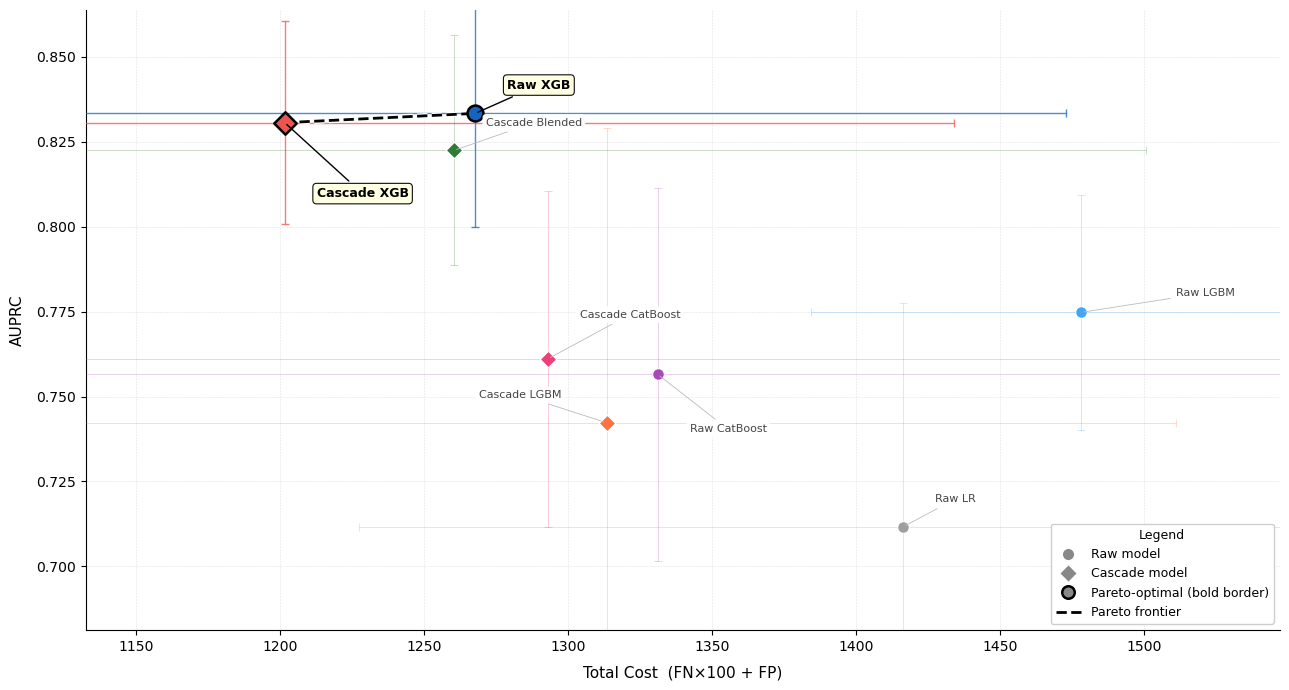

Pareto plot saved.

Pareto-optimal models:
      model  total_cost_mean  total_cost_std  auprc_mean  auprc_std
Cascade XGB           1201.6      232.417297    0.830597   0.029851
    Raw XGB           1267.8      205.145558    0.833339   0.033539


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

MODEL_ORDER = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended'
]

colors = {
    'Raw LR'          : '#9E9E9E',
    'Raw LGBM'        : '#42A5F5',
    'Raw XGB'         : '#1565C0',
    'Raw CatBoost'    : '#AB47BC',
    'Cascade XGB'     : '#EF5350',
    'Cascade LGBM'    : '#FF7043',
    'Cascade CatBoost': '#EC407A',
    'Cascade Blended' : '#2E7D32',
}

# ── Pareto function ──────────────────────────────────────────────────────────
def get_pareto(df):
    pareto = []
    for i, r in df.iterrows():
        dominated = any(
            (o['total_cost_mean'] <= r['total_cost_mean'] and
             o['auprc_mean']      >= r['auprc_mean'] and
             (o['total_cost_mean'] < r['total_cost_mean'] or
              o['auprc_mean']      > r['auprc_mean']))
            for _, o in df.iterrows() if _ != i
        )
        if not dominated:
            pareto.append(i)
    return df.loc[pareto].sort_values('total_cost_mean')

# ── Build mean-aggregated points ─────────────────────────────────────────────
pareto_points = []
for model in MODEL_ORDER:
    grp = results_df[results_df['model'] == model]
    if len(grp) == 0:
        continue
    pareto_points.append({
        'model'          : model,
        'total_cost_mean': grp['total_cost'].mean(),
        'total_cost_std' : grp['total_cost'].std(),
        'auprc_mean'     : grp['auprc'].mean(),
        'auprc_std'      : grp['auprc'].std(),
        'flops'          : grp['flops_per_1000'].mean(),
    })

pp_df      = pd.DataFrame(pareto_points)
pareto_df  = get_pareto(pp_df)
pareto_idx = set(pareto_df.index)

# # ── Print actual data coordinates first (use these to set offsets) ───────────
# print("Model coordinates (use for LABEL_OFFSETS tuning):")
# print(pp_df[['model','total_cost_mean','auprc_mean']].to_string(index=False))

x_range = pp_df['total_cost_mean'].max() - pp_df['total_cost_mean'].min()
y_range = pp_df['auprc_mean'].max()      - pp_df['auprc_mean'].min()

# ── Label offsets in DATA coordinates (scaled to actual axis range) ───────────
# Rule of thumb: dx ~ 3-5% of x_range, dy ~ 3-5% of y_range
# Adjust per model to avoid collision
LABEL_OFFSETS = {
    'Cascade Blend'   : (-x_range * 0.18,  y_range * 0.08),   # left + up
    'Cascade XGB'     : ( x_range * 0.04, -y_range * 0.18),   # right + down
    'Raw XGB'         : ( x_range * 0.04,  y_range * 0.06),
    'Raw LGBM'        : ( x_range * 0.12,  y_range * 0.04),
    'Raw CatBoost'    : ( x_range * 0.04, -y_range * 0.14),
    'Cascade LGBM'    : (-x_range * 0.16,  y_range * 0.06),
    'Cascade CatBoost': ( x_range * 0.04,  y_range * 0.10),
    'Raw LR'          : ( x_range * 0.04,  y_range * 0.06),
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── 1. Error bars — drawn first, behind everything ───────────────────────────
for _, row in pp_df.iterrows():
    is_pareto = _ in pareto_idx
    ax.errorbar(
        row['total_cost_mean'], row['auprc_mean'],
        xerr=row['total_cost_std'],
        yerr=row['auprc_std'],
        fmt='none',
        ecolor=colors.get(row['model'], '#999999'),
        elinewidth=1.0 if is_pareto else 0.6,
        capsize=3,
        capthick=1.0 if is_pareto else 0.6,
        alpha=0.75 if is_pareto else 0.30,
        zorder=3,
    )

# ── 2. Markers ────────────────────────────────────────────────────────────────
for _, row in pp_df.iterrows():
    is_pareto  = _ in pareto_idx
    is_cascade = 'Raw' not in row['model']
    ax.scatter(
        row['total_cost_mean'], row['auprc_mean'],
        marker='D' if is_cascade else 'o',
        s=130 if is_pareto else 70,
        color=colors.get(row['model'], '#999999'),
        edgecolors='black' if is_pareto else 'white',
        linewidths=1.8 if is_pareto else 0.8,
        zorder=5,
    )

# ── 3. Pareto frontier line (white outline so it shows over error bars) ───────
if len(pareto_df) > 1:
    ax.plot(
        pareto_df['total_cost_mean'],
        pareto_df['auprc_mean'],
        color='black', linestyle='--', linewidth=2.0,
        zorder=4,
        path_effects=[
            pe.Stroke(linewidth=4.0, foreground='white'),
            pe.Normal()
        ],
        label='_nolegend_',
    )

# ── 4. Labels in data coordinates with arrow back to marker ──────────────────
for _, row in pp_df.iterrows():
    is_pareto = _ in pareto_idx
    dx, dy    = LABEL_OFFSETS.get(row['model'], (x_range * 0.04, y_range * 0.06))

    ax.annotate(
        row['model'],
        xy=(row['total_cost_mean'], row['auprc_mean']),
        xytext=(row['total_cost_mean'] + dx, row['auprc_mean'] + dy),
        textcoords='data',
        fontsize=9 if is_pareto else 8,
        fontweight='bold' if is_pareto else 'normal',
        color='black' if is_pareto else '#444444',
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='lightyellow' if is_pareto else 'white',
            ec='black' if is_pareto else 'none',
            alpha=0.95,
            linewidth=0.8,
        ),
        arrowprops=dict(
            arrowstyle='-',
            color='black' if is_pareto else '#bbbbbb',
            lw=1.0 if is_pareto else 0.6,
        ),
        zorder=7,
    )

# ── 5. Legend (manual) ────────────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markersize=9, label='Raw model'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#888888',
               markersize=9, label='Cascade model'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markeredgecolor='black', markeredgewidth=1.8,
               markersize=9, label='Pareto-optimal (bold border)'),
    plt.Line2D([0],[0], linestyle='--', color='black',
               linewidth=2.0, label='Pareto frontier'),
]
ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=9,
    framealpha=0.95,
    edgecolor='#cccccc',
    title='Legend', title_fontsize=9,
)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('Total Cost  (FN×100 + FP)',
              fontsize=11, labelpad=8)
ax.set_ylabel('AUPRC',
              fontsize=11, labelpad=8)
# ax.set_title('Cost–Performance Pareto Frontier\nMean ± Std across 5 Seeds',
#              fontsize=13, fontweight='bold', pad=14)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35, color='#aaaaaa')
ax.spines[['top','right']].set_visible(False)

# Pad axes so labels don't get clipped at edges
ax.set_xlim(pp_df['total_cost_mean'].min() - x_range * 0.25,
            pp_df['total_cost_mean'].max() + x_range * 0.25)
ax.set_ylim(pp_df['auprc_mean'].min()      - y_range * 0.25,
            pp_df['auprc_mean'].max()      + y_range * 0.25)

plt.tight_layout()
plt.savefig('pareto_frontier_multiseed.png', dpi=300, bbox_inches='tight')
plt.show()

print('Pareto plot saved.')
print('\nPareto-optimal models:')
print(pareto_df[['model','total_cost_mean','total_cost_std',
                 'auprc_mean','auprc_std']].to_string(index=False))

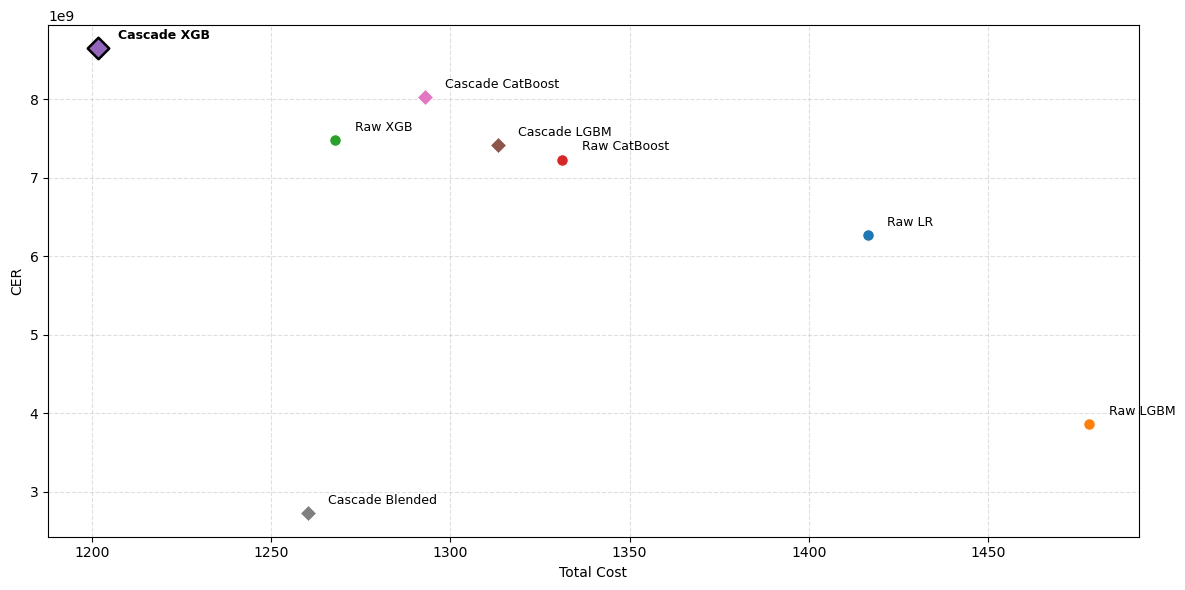

Pareto-optimal models:
         Model  Total Cost           CER
4  Cascade XGB      1201.6  8.645445e+09


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# ── Load your pub_df CSV ─────────────────────────────────────────────
# If you already have pub_df as a DataFrame, skip this
pub_df = pd.read_csv("../Downloads/table1_main_results.csv")  # replace with actual CSV path

# ── Clean numeric columns ─────────────────────────────────────────────
# Remove commas and convert CER and Total Cost to float
pub_df['CER'] = pub_df['CER'].str.replace(',', '').astype(float)
pub_df['Total Cost'] = pub_df['Total Cost'].str.split(' ').str[0].astype(float)  # extract mean if ± exists

MODEL_ORDER = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended'
]

colors = {
    'Raw LR': '#1f77b4',
    'Raw LGBM': '#ff7f0e',
    'Raw XGB': '#2ca02c',
    'Raw CatBoost': '#d62728',
    'Cascade XGB': '#9467bd',
    'Cascade LGBM': '#8c564b',
    'Cascade CatBoost': '#e377c2',
    'Cascade Blended': '#7f7f7f'
}

# ── Build mean points for Pareto ─────────────────────────────────────
pp_df = pub_df[['Model', 'Total Cost', 'CER']].copy()
pp_df = pp_df.set_index('Model').loc[MODEL_ORDER].reset_index()

# ── Pareto function (maximize CER, minimize Total Cost) ──────────────
def get_pareto(df):
    pareto = []
    for i, r in df.iterrows():
        dominated = any(
            (o['Total Cost'] <= r['Total Cost'] and
             o['CER'] >= r['CER'] and
             (o['Total Cost'] < r['Total Cost'] or o['CER'] > r['CER']))
            for _, o in df.iterrows() if _ != i
        )
        if not dominated:
            pareto.append(i)
    return df.loc[pareto].sort_values('Total Cost')

pareto_df = get_pareto(pp_df)
pareto_idx = set(pareto_df.index)

# ── Plot Pareto frontier ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12,6))

x_range = pp_df['Total Cost'].max() - pp_df['Total Cost'].min()
y_range = pp_df['CER'].max() - pp_df['CER'].min()

LABEL_OFFSETS = {
    'Raw LR': (x_range*0.02, y_range*0.02),
    'Raw LGBM': (x_range*0.02, y_range*0.02),
    'Raw XGB': (x_range*0.02, y_range*0.02),
    'Raw CatBoost': (x_range*0.02, y_range*0.02),
    'Cascade XGB': (x_range*0.02, y_range*0.02),
    'Cascade LGBM': (x_range*0.02, y_range*0.02),
    'Cascade CatBoost': (x_range*0.02, y_range*0.02),
    'Cascade Blended': (x_range*0.02, y_range*0.02),
}

# Plot points
for _, row in pp_df.iterrows():
    is_pareto = _ in pareto_idx
    is_cascade = 'Raw' not in row['Model']
    ax.scatter(
        row['Total Cost'], row['CER'],
        marker='D' if is_cascade else 'o',
        s=120 if is_pareto else 70,
        color=colors.get(row['Model'], '#999999'),
        edgecolors='black' if is_pareto else 'white',
        linewidths=1.8 if is_pareto else 0.8,
        zorder=5,
    )

# Pareto line
ax.plot(
    pareto_df['Total Cost'], pareto_df['CER'],
    linestyle='--', color='black', linewidth=2,
    path_effects=[pe.Stroke(linewidth=4, foreground='white'), pe.Normal()],
    zorder=4
)

# Labels
for _, row in pp_df.iterrows():
    dx, dy = LABEL_OFFSETS.get(row['Model'], (x_range*0.02, y_range*0.02))
    ax.annotate(
        row['Model'],
        xy=(row['Total Cost'], row['CER']),
        xytext=(row['Total Cost'] + dx, row['CER'] + dy),
        fontsize=9, fontweight='bold' if _ in pareto_idx else 'normal'
    )

ax.set_xlabel('Total Cost')
ax.set_ylabel('CER')
#ax.set_title('Cost–Performance Pareto Frontier (CER)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('pareto_frontier_CER.png', dpi=300, bbox_inches='tight')
plt.show()

print("Pareto-optimal models:")
print(pareto_df)

## Raw model vs Cascade model metrics comparison

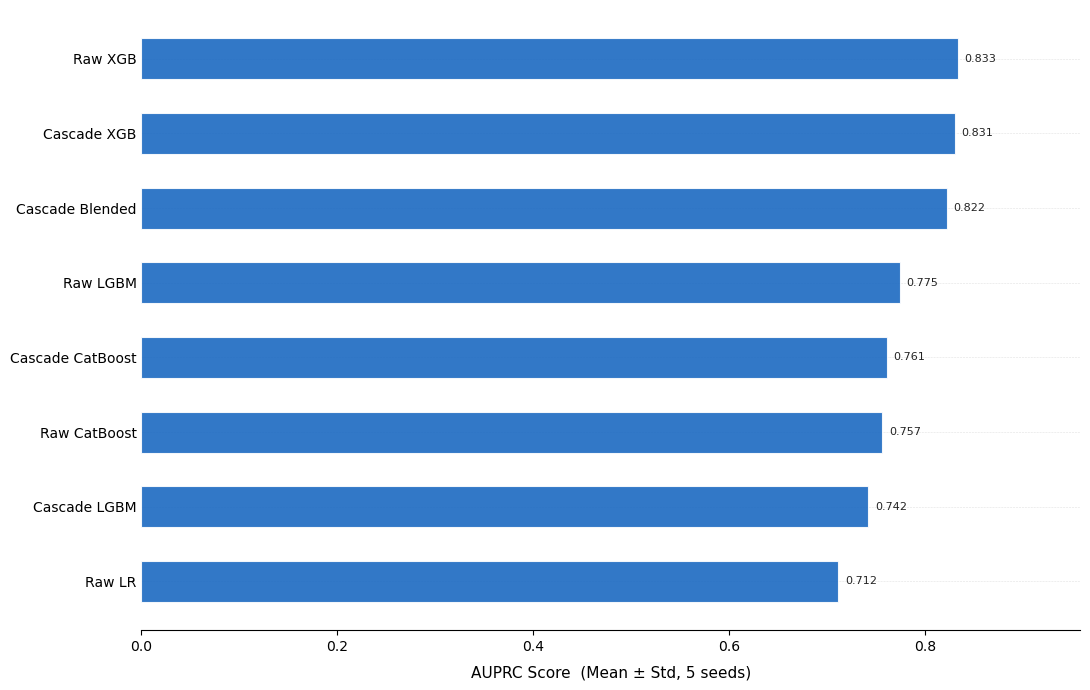

Saved: barchart_auprc.png


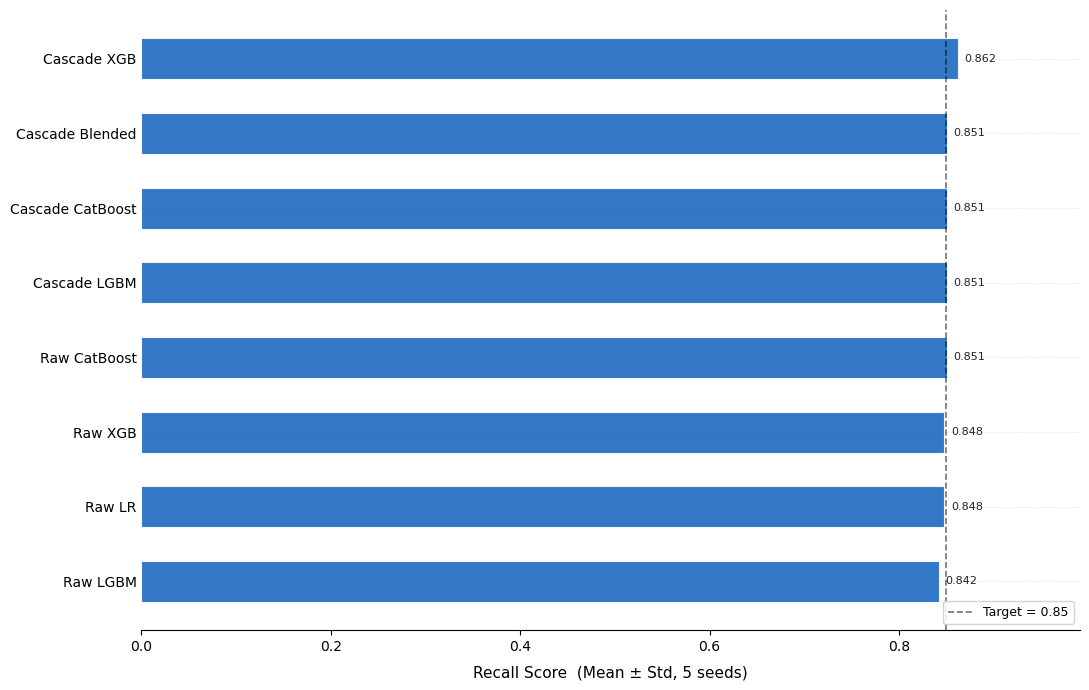

Saved: barchart_recall.png


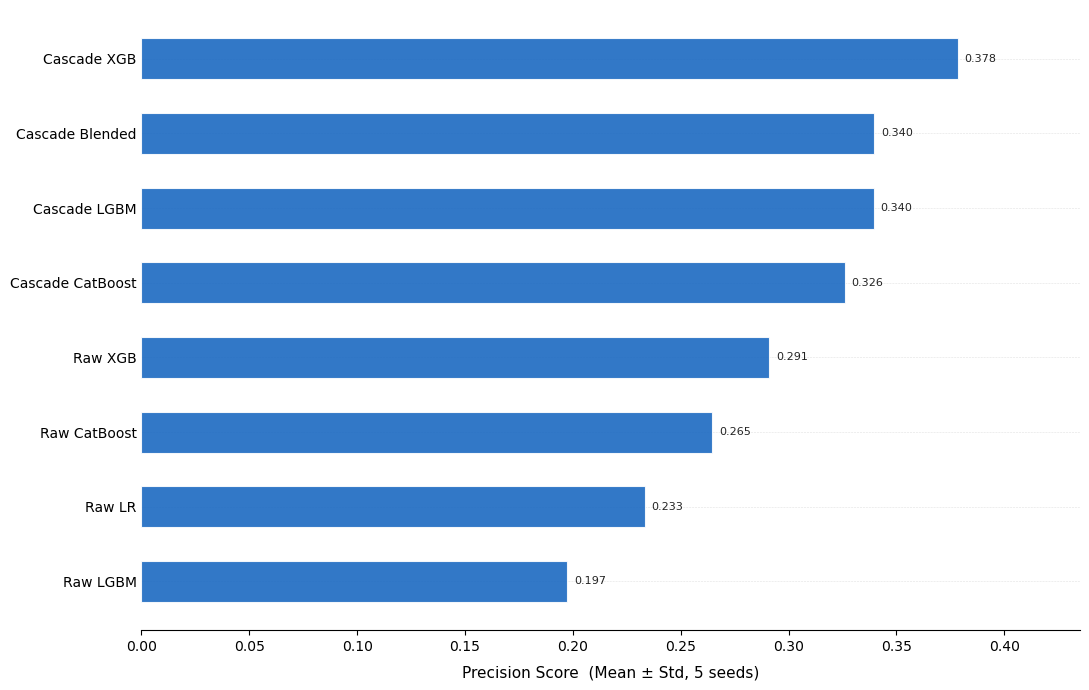

Saved: barchart_precision.png


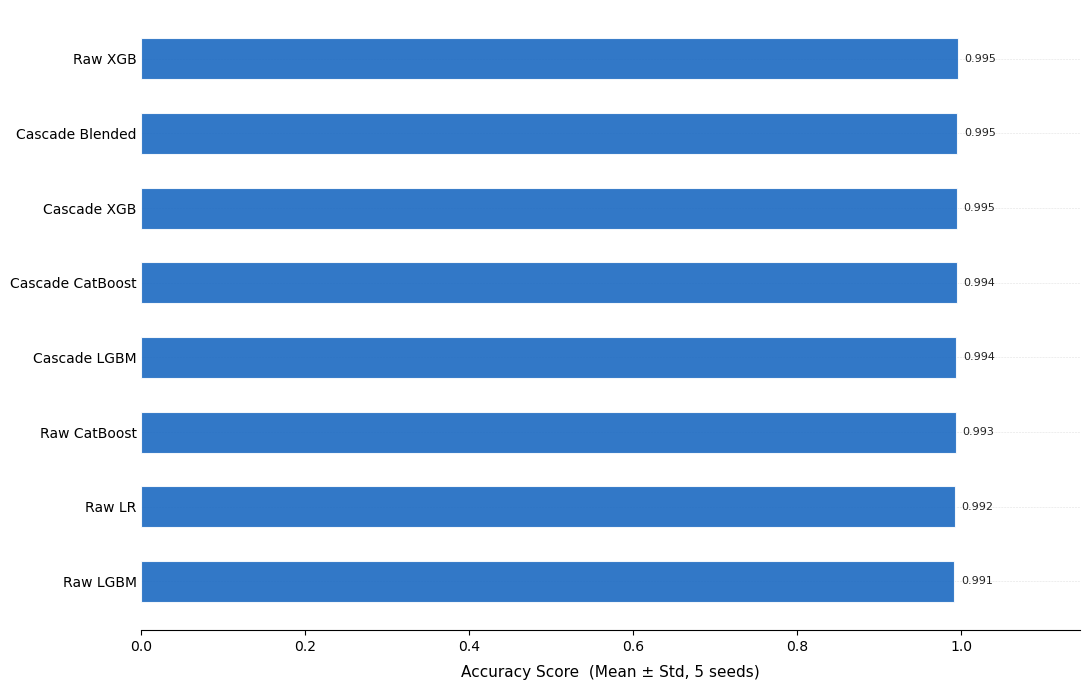

Saved: barchart_accuracy.png


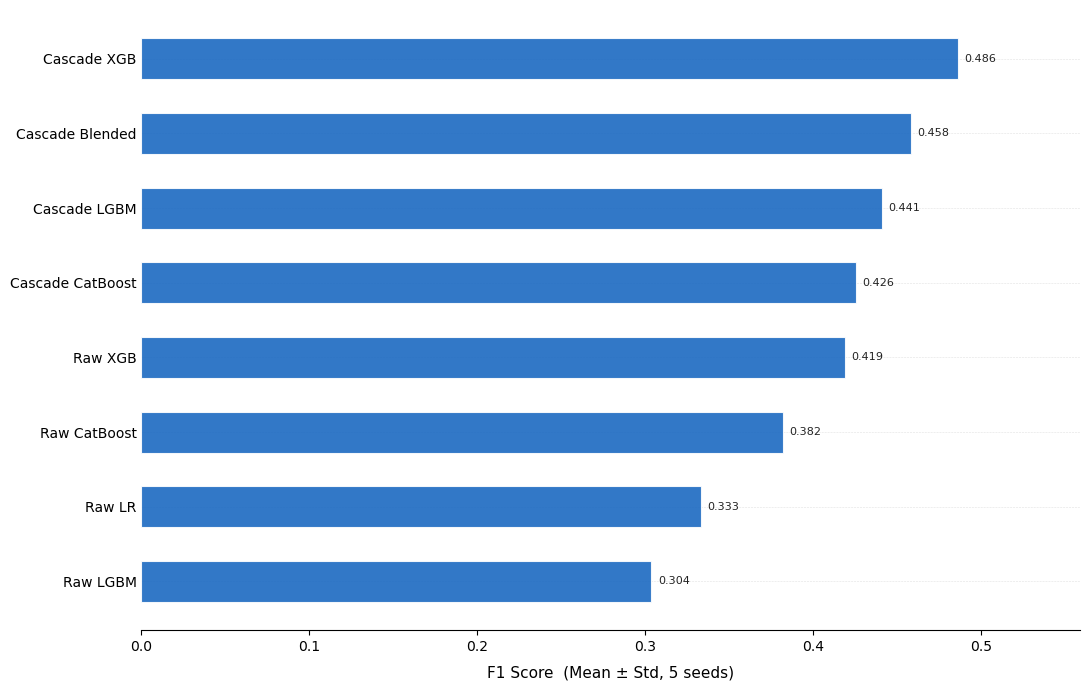

Saved: barchart_f1.png


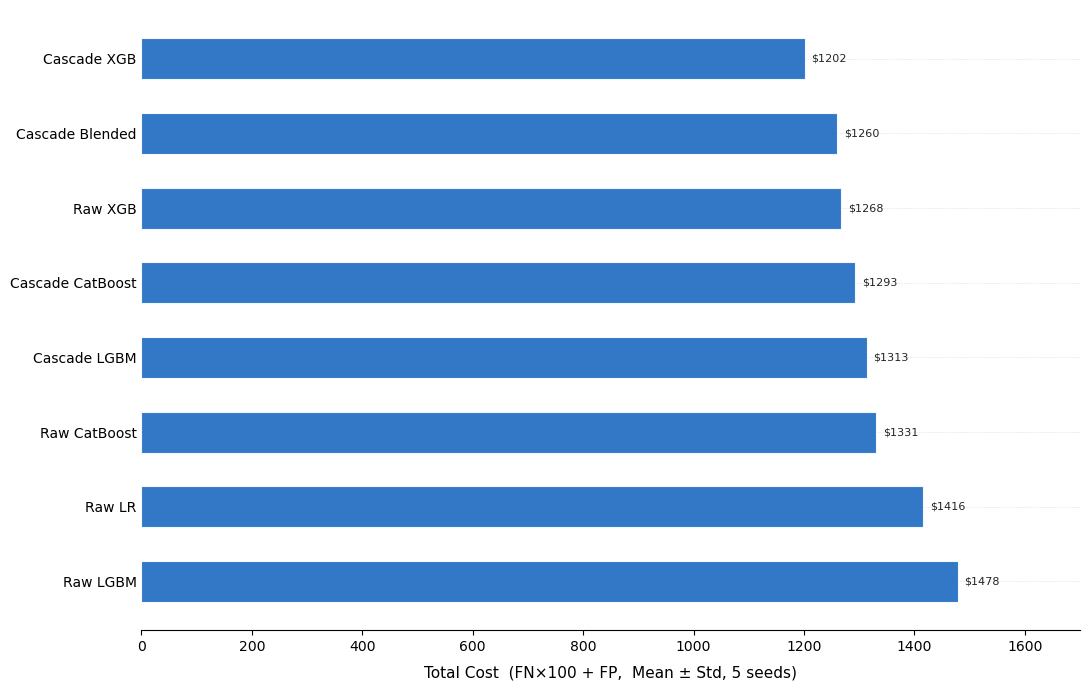

Saved: barchart_total_cost.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
ALL_12_MODELS = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended',
]

def mean_std(model_name, metric):
    vals = results_df[results_df['model'] == model_name][metric].values
    return (vals.mean(), vals.std()) if len(vals) > 0 else (np.nan, 0)

def save_show(fname):
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

def make_bar_chart(metric, ylabel, is_cost=False, fmt='.3f', target_line=None):

    # ── Build data and sort ───────────────────────────────────────────────────
    data = []
    for model in ALL_12_MODELS:
        m, s = mean_std(model, metric)
        data.append({'model': model, 'mean': m, 'std': s})

    data_df = pd.DataFrame(data)
    # For cost: ascending=False puts highest cost at bottom (worst at bottom)
    # For others: ascending=True puts lowest at bottom (best at top)
    data_df = data_df.sort_values(
        'mean',
        ascending=False if is_cost else True
    ).reset_index(drop=True)

    means  = data_df['mean'].tolist()
    stds   = data_df['std'].tolist()
    labels = data_df['model'].tolist()
    y_pos  = np.arange(len(labels))

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # ── Bars — no xerr ────────────────────────────────────────────────────────
    ax.barh(
        y_pos, means,
        height=0.55,
        color='#1565C0',
        edgecolor='white',
        linewidth=0.8,
        alpha=0.88,
    )


    # ── Value labels — tight to bar end ───────────────────────────────────────
    x_max = max(m for m in means if not np.isnan(m))
    for i, (val, std) in enumerate(zip(means, stds)):
        if np.isnan(val):
            continue
        lbl = f'${val:.0f}' if is_cost else f'{val:{fmt}}'
        ax.text(
            val + x_max * 0.008, i,
            lbl,
            va='center', ha='left',
            fontsize=8, color='#222222',
        )

    # ── Target line ───────────────────────────────────────────────────────────
    if target_line is not None:
        ax.axvline(target_line, color='black', linestyle='--',
                   linewidth=1.2, alpha=0.55,
                   label=f'Target = {target_line}')
        ax.legend(fontsize=9, framealpha=0.85,loc='lower right')

    # ── Y-axis — all black ────────────────────────────────────────────────────
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10, color='black')

    # ── Horizontal grid only ──────────────────────────────────────────────────
    ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.35, color='#aaaaaa')
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

    ax.set_xlabel(ylabel, fontsize=11, labelpad=8)
    ax.set_xlim(0, x_max * 1.15)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

    plt.tight_layout()
    return fig, ax


# ─────────────────────────────────────────────────────────────────────────────
# 1. AUPRC
# ─────────────────────────────────────────────────────────────────────────────
make_bar_chart('auprc', 'AUPRC Score  (Mean ± Std, 5 seeds)')
save_show('barchart_auprc.png')

# ─────────────────────────────────────────────────────────────────────────────
# 2. Recall
# ─────────────────────────────────────────────────────────────────────────────
make_bar_chart('recall', 'Recall Score  (Mean ± Std, 5 seeds)', target_line=0.85)
save_show('barchart_recall.png')

# ─────────────────────────────────────────────────────────────────────────────
# 3. Precision
# ─────────────────────────────────────────────────────────────────────────────
make_bar_chart('precision', 'Precision Score  (Mean ± Std, 5 seeds)')
save_show('barchart_precision.png')

# ─────────────────────────────────────────────────────────────────────────────
# 4. Accuracy
# ─────────────────────────────────────────────────────────────────────────────
make_bar_chart('accuracy', 'Accuracy Score  (Mean ± Std, 5 seeds)')
save_show('barchart_accuracy.png')

# ─────────────────────────────────────────────────────────────────────────────
# 5. F1
# ─────────────────────────────────────────────────────────────────────────────
make_bar_chart('f1', 'F1 Score  (Mean ± Std, 5 seeds)')
save_show('barchart_f1.png')

# ─────────────────────────────────────────────────────────────────────────────
# 6. Total Cost
# ─────────────────────────────────────────────────────────────────────────────
make_bar_chart('total_cost', 'Total Cost  (FN×100 + FP,  Mean ± Std, 5 seeds)',
               is_cost=True, fmt='.0f')
save_show('barchart_total_cost.png')

## AUPRC Curve for all 8 models

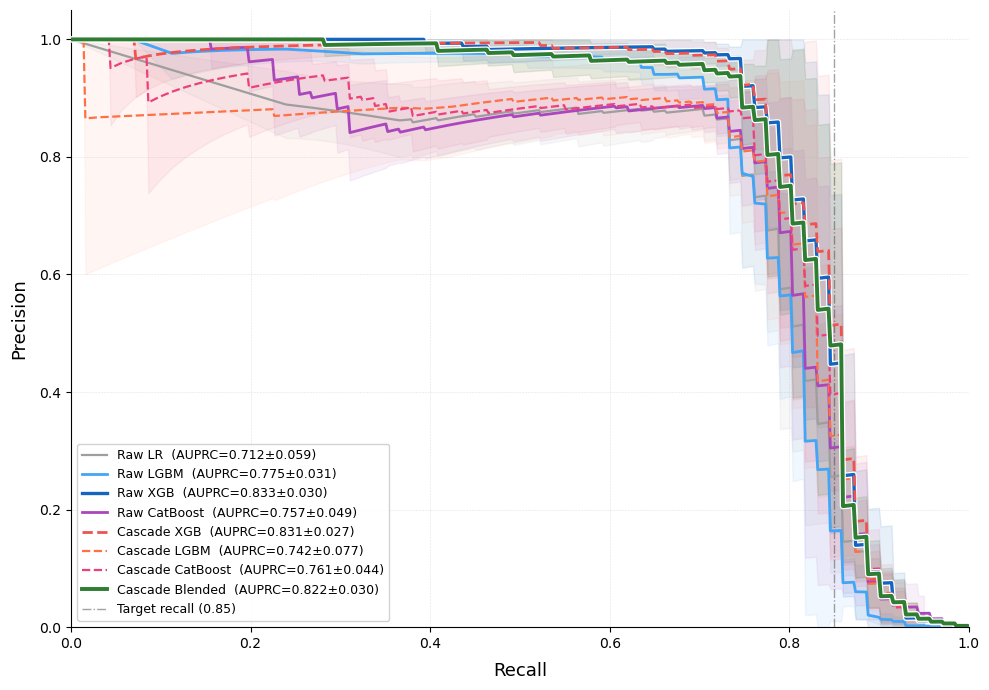

Saved: auprc_curve.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. AUPRC Curve — all 8 models, publication-ready
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# ── Explicit model list — all 8, in display order ────────────────────────────
ALL_MODELS = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended'
]

# ── Per-model style: solid=Raw, dashed=Cascade, green=Blended (hero) ──────────
MODEL_STYLE = {
    'Raw LR'          : {'color': '#9E9E9E', 'ls': '-',  'lw': 1.6, 'z': 2, 'alpha': 0.08},
    'Raw LGBM'        : {'color': '#42A5F5', 'ls': '-',  'lw': 2.0, 'z': 3, 'alpha': 0.08},
    'Raw XGB'         : {'color': '#1565C0', 'ls': '-',  'lw': 2.4, 'z': 4, 'alpha': 0.10},
    'Raw CatBoost'    : {'color': '#AB47BC', 'ls': '-',  'lw': 2.0, 'z': 3, 'alpha': 0.08},
    'Cascade XGB'     : {'color': '#EF5350', 'ls': '--', 'lw': 2.0, 'z': 4, 'alpha': 0.08},
    'Cascade LGBM'    : {'color': '#FF7043', 'ls': '--', 'lw': 1.6, 'z': 3, 'alpha': 0.06},
    'Cascade CatBoost': {'color': '#EC407A', 'ls': '--', 'lw': 1.6, 'z': 3, 'alpha': 0.08},
    'Cascade Blended' : {'color': '#2E7D32', 'ls': '-',  'lw': 2.8, 'z': 6, 'alpha': 0.12},
}

recall_grid = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for model in ALL_MODELS:
    s     = MODEL_STYLE[model]
    grp   = results_df[results_df['model'] == model]
    auprc_mean, auprc_std = mean_std(model, 'auprc')
    label = f'{model}  (AUPRC={auprc_mean:.3f}±{auprc_std:.3f})'

    # ── Fallback: no raw arrays stored → draw empty line for legend entry ─────
    if len(grp) == 0 or 'y_true' not in grp.columns or 'y_prob' not in grp.columns:
        ax.plot([], [], color=s['color'], ls=s['ls'], lw=s['lw'], label=label)
        continue

    # ── Interpolate each seed's PR curve onto common recall grid ──────────────
    prec_interp_all = []
    for _, row in grp.iterrows():
        y_true = np.array(row['y_true'])
        y_prob = np.array(row['y_prob'])
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        prec_interp_all.append(np.interp(recall_grid, rec[::-1], prec[::-1]))

    prec_mean = np.mean(prec_interp_all, axis=0)
    prec_std  = np.std(prec_interp_all,  axis=0)

    # Clip shading to recall ≤ 0.95 to avoid noisy cliff region
    mask = recall_grid <= 0.95
    ax.fill_between(
        recall_grid[mask],
        np.clip(prec_mean[mask] - prec_std[mask], 0, 1),
        np.clip(prec_mean[mask] + prec_std[mask], 0, 1),
        color=s['color'], alpha=s['alpha'], zorder=1,
    )

    # White outline glow on hero models so they stand out
    glow = ([pe.Stroke(linewidth=s['lw'] + 1.8, foreground='white'), pe.Normal()]
            if model in ('Raw XGB', 'Cascade Blended') else [])
    ax.plot(recall_grid, prec_mean,
            color=s['color'], ls=s['ls'], lw=s['lw'],
            zorder=s['z'], label=label, path_effects=glow)

# ── Target recall reference line ──────────────────────────────────────────────
ax.axvline(0.85, color='#333333', linestyle='-.', linewidth=1.0,
           alpha=0.45, zorder=1, label='Target recall (0.85)')

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Recall',    fontsize=13, labelpad=8)
ax.set_ylabel('Precision', fontsize=13, labelpad=8)
ax.grid(linestyle='--', linewidth=0.4, alpha=0.35, color='#aaaaaa')
ax.spines[['top', 'right']].set_visible(False)


# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(
    fontsize=9,
    loc='lower left',
    framealpha=0.88,
    edgecolor='#cccccc',
)

plt.tight_layout()
save_show('auprc_curve.png')

## Pareto Frontier — AUPRC VS Cost

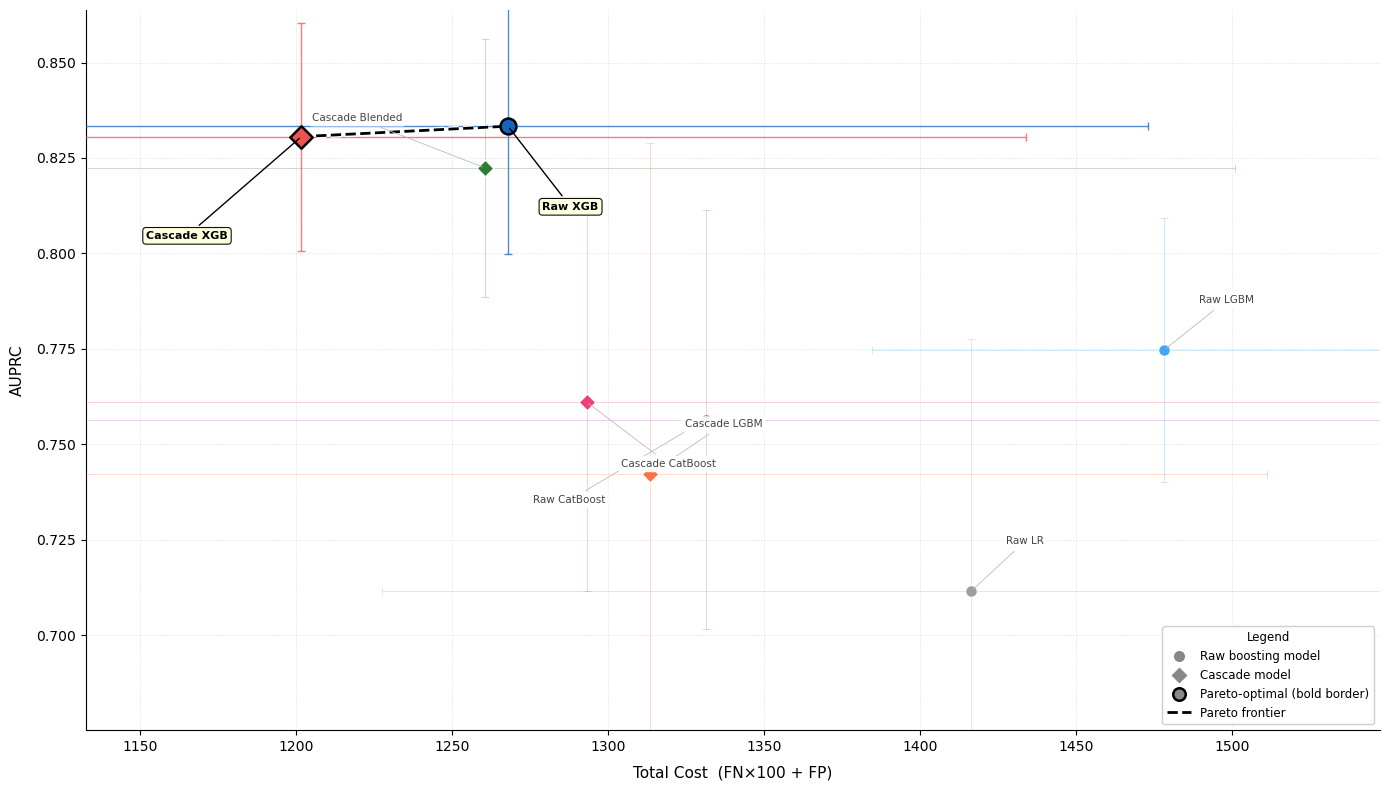

Cost-AUPRC frontier plot saved.

Pareto-optimal models (AUPRC vs Total Cost):
      model  cost_mean   cost_std  auprc_mean  auprc_std
Cascade XGB     1201.6 232.417297    0.830597   0.029851
    Raw XGB     1267.8 205.145558    0.833339   0.033539


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd
import numpy as np

# ════════════════════════════════════════════════════════════════════════════
# PARETO: AUPRC vs Total Cost — all 8 models
# ════════════════════════════════════════════════════════════════════════════

def get_pareto(df):
    """Lower Cost + Higher AUPRC = better."""
    pareto = []
    for i, r in df.iterrows():
        dominated = any(
            (o['cost_mean']   <= r['cost_mean'] and
             o['auprc_mean']  >= r['auprc_mean'] and
             (o['cost_mean']  <  r['cost_mean'] or
              o['auprc_mean'] >  r['auprc_mean']))
            for _, o in df.iterrows() if _ != i
        )
        if not dominated:
            pareto.append(i)
    return df.loc[pareto].sort_values('cost_mean')

# ── All 12 models ─────────────────────────────────────────────────────────────
ALL_COST_MODELS = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended',
]

colors_cost = {
    'Raw LR'             : '#9E9E9E',
    'Raw LGBM'           : '#42A5F5',
    'Raw XGB'            : '#1565C0',
    'Raw CatBoost'       : '#AB47BC',
    'Cascade XGB'        : '#EF5350',
    'Cascade LGBM'       : '#FF7043',
    'Cascade CatBoost'   : '#EC407A',
    'Cascade Blended'    : '#2E7D32',
}

def get_marker(model):
    if 'Raw' in model: return 'o'
    return 'D'

# ── Build points ──────────────────────────────────────────────────────────────
cost_points = []
for model in ALL_COST_MODELS:
    grp = results_df[results_df['model'] == model]
    if len(grp) == 0:
        continue
    cost_points.append({
        'model'     : model,
        'cost_mean' : grp['total_cost'].mean(),
        'cost_std'  : grp['total_cost'].std(),
        'auprc_mean': grp['auprc'].mean(),
        'auprc_std' : grp['auprc'].std(),
    })

cost_df = pd.DataFrame(cost_points)

# ── Pareto frontier — all 8 models ──────────────────────────────────────────
pareto_cost   = get_pareto(cost_df)
pareto_models = set(pareto_cost['model'].values)

x_range = cost_df['cost_mean'].max()  - cost_df['cost_mean'].min()
y_range = cost_df['auprc_mean'].max() - cost_df['auprc_mean'].min()

LABEL_OFFSETS = {
    'Raw LR'             : ( x_range * 0.04,  y_range * 0.10),
    'Raw LGBM'           : ( x_range * 0.04,  y_range * 0.10),
    'Raw XGB'            : ( x_range * 0.04, -y_range * 0.18),
    'Raw CatBoost'       : (-x_range * 0.20, -y_range * 0.18),
    'Cascade XGB'        : (-x_range * 0.18, -y_range * 0.22),
    'Cascade LGBM'       : ( x_range * 0.04,  y_range * 0.10),
    'Cascade CatBoost'   : ( x_range * 0.04, -y_range * 0.14),
    'Cascade Blended'    : (-x_range * 0.20,  y_range * 0.10),
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Error bars ────────────────────────────────────────────────────────────────
for _, row in cost_df.iterrows():
    is_p = row['model'] in pareto_models
    ax.errorbar(
        row['cost_mean'], row['auprc_mean'],
        xerr=row['cost_std'], yerr=row['auprc_std'],
        fmt='none',
        ecolor=colors_cost.get(row['model'], '#999999'),
        elinewidth=1.0 if is_p else 0.6,
        capsize=3, capthick=1.0 if is_p else 0.6,
        alpha=0.75 if is_p else 0.30,
        zorder=3,
    )

# ── Markers ───────────────────────────────────────────────────────────────────
for _, row in cost_df.iterrows():
    is_p = row['model'] in pareto_models
    ax.scatter(
        row['cost_mean'], row['auprc_mean'],
        marker=get_marker(row['model']),
        s=130 if is_p else 70,
        color=colors_cost.get(row['model'], '#999999'),
        edgecolors='black' if is_p else 'white',
        linewidths=1.8 if is_p else 0.8,
        zorder=5,
    )

# ── Pareto frontier line ──────────────────────────────────────────────────────
if len(pareto_cost) > 1:
    ax.plot(
        pareto_cost['cost_mean'], pareto_cost['auprc_mean'],
        color='black', linestyle='--', linewidth=2.0, zorder=4,
        path_effects=[pe.Stroke(linewidth=4.0, foreground='white'), pe.Normal()],
        label='_nolegend_',
    )

# ── Labels ────────────────────────────────────────────────────────────────────
for _, row in cost_df.iterrows():
    is_p   = row['model'] in pareto_models
    dx, dy = LABEL_OFFSETS.get(row['model'], (x_range * 0.04, y_range * 0.06))
    ax.annotate(
        row['model'],
        xy=(row['cost_mean'], row['auprc_mean']),
        xytext=(row['cost_mean'] + dx, row['auprc_mean'] + dy),
        textcoords='data',
        fontsize=8 if is_p else 7.5,
        fontweight='bold' if is_p else 'normal',
        color='black' if is_p else '#444444',
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='lightyellow' if is_p else 'white',
                  ec='black' if is_p else 'none',
                  alpha=0.95, linewidth=0.8),
        arrowprops=dict(arrowstyle='-',
                        color='black' if is_p else '#bbbbbb',
                        lw=1.0 if is_p else 0.6),
        zorder=7,
    )


# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markersize=9, label='Raw boosting model'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#888888',
               markersize=9, label='Cascade model'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markeredgecolor='black', markeredgewidth=1.8,
               markersize=9, label='Pareto-optimal (bold border)'),
    plt.Line2D([0],[0], linestyle='--', color='black',
               linewidth=2.0, label='Pareto frontier'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8.5,
          framealpha=0.95, edgecolor='#cccccc',
          title='Legend', title_fontsize=8.5)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('Total Cost  (FN×100 + FP)',
              fontsize=11, labelpad=8)
ax.set_ylabel('AUPRC', fontsize=11, labelpad=8)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35, color='#aaaaaa')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(cost_df['cost_mean'].min() - x_range * 0.25,
            cost_df['cost_mean'].max() + x_range * 0.25)
ax.set_ylim(cost_df['auprc_mean'].min() - y_range * 0.30,
            cost_df['auprc_mean'].max() + y_range * 0.25)

plt.tight_layout()
plt.savefig('pareto_cost_auprc_vs_cost.png', dpi=300, bbox_inches='tight')
plt.show()

print('Cost-AUPRC frontier plot saved.')
print('\nPareto-optimal models (AUPRC vs Total Cost):')
print(pareto_cost[['model','cost_mean','cost_std','auprc_mean','auprc_std']]
      .to_string(index=False))

## Pareto Scatter- AUPRC vs CO₂ per inference (CER frontier) 

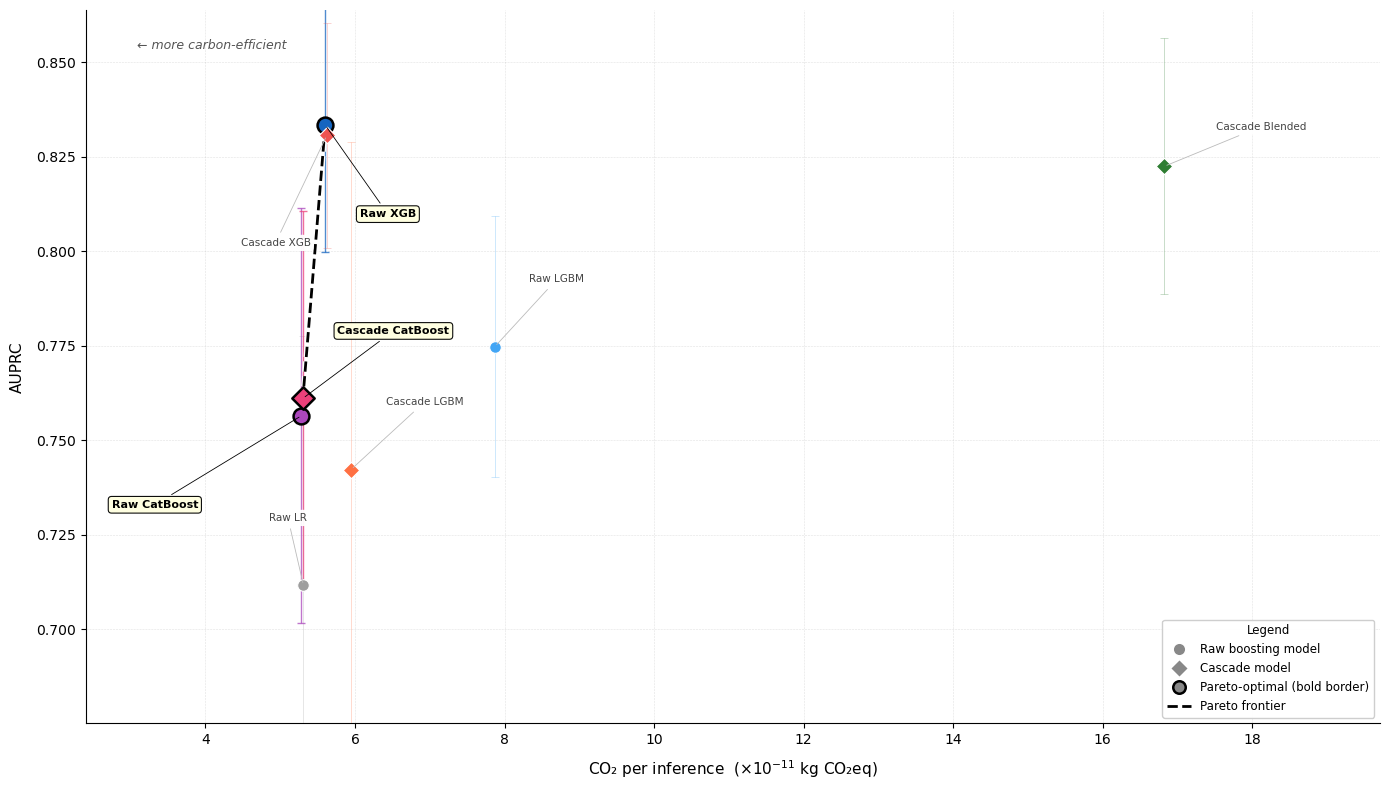

CER frontier plot saved.

Pareto-optimal models (AUPRC vs CO₂):
           model     co2_mean  auprc_mean  auprc_std          cer
    Raw CatBoost 5.283207e-11    0.756512   0.054897 1.431917e+10
Cascade CatBoost 5.302702e-11    0.761092   0.049425 1.435291e+10
         Raw XGB 5.601805e-11    0.833339   0.033539 1.487626e+10


In [15]:
import matplotlib.patheffects as pe

# ════════════════════════════════════════════════════════════════════════════
# PARETO: AUPRC vs CO₂ per inference  (CER frontier) — all 8 models
# ════════════════════════════════════════════════════════════════════════════

def get_pareto_cer(df):
    """Lower CO₂ + Higher AUPRC = better."""
    pareto = []
    for i, r in df.iterrows():
        dominated = any(
            (o['co2_mean']    <= r['co2_mean'] and
             o['auprc_mean']  >= r['auprc_mean'] and
             (o['co2_mean']   <  r['co2_mean'] or
              o['auprc_mean'] >  r['auprc_mean']))
            for _, o in df.iterrows() if _ != i
        )
        if not dominated:
            pareto.append(i)
    return df.loc[pareto].sort_values('co2_mean')

# ── All 12 models ─────────────────────────────────────────────────────────────
ALL_CER_MODELS = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended',
]

colors_cer = {
    'Raw LR'             : '#9E9E9E',
    'Raw LGBM'           : '#42A5F5',
    'Raw XGB'            : '#1565C0',
    'Raw CatBoost'       : '#AB47BC',
    'Cascade XGB'        : '#EF5350',
    'Cascade LGBM'       : '#FF7043',
    'Cascade CatBoost'   : '#EC407A',
    'Cascade Blended'    : '#2E7D32',
}

def get_marker(model):
    if 'Raw' in model: return 'o'
    return 'D'

# ── Build points ──────────────────────────────────────────────────────────────
cer_points = []
for model in ALL_CER_MODELS:
    grp    = results_df[results_df['model'] == model]
    em_row = em_agg[em_agg['Model'] == model]
    if len(grp) == 0 or len(em_row) == 0:
        continue
    co2_kg_per_1 = float(em_row['CO2_per_1k_inf_g'].values[0]) / 1_000 / 1_000
    cer_points.append({
        'model'     : model,
        'co2_mean'  : co2_kg_per_1,
        'auprc_mean': grp['auprc'].mean(),
        'auprc_std' : grp['auprc'].std(),
        'cer'       : grp['auprc'].mean() / co2_kg_per_1 if co2_kg_per_1 > 0 else float('inf'),
    })

cer_df = pd.DataFrame(cer_points)

# ── Pareto frontier — all models included ─────────────────────────────────────
pareto_cer    = get_pareto_cer(cer_df)
pareto_models = set(pareto_cer['model'].values)

# ── Scale CO₂ for readable axis ───────────────────────────────────────────────
SCALE = 1e11
cer_df['co2_scaled']     = cer_df['co2_mean']    * SCALE
pareto_cer['co2_scaled'] = pareto_cer['co2_mean'] * SCALE

x_range_c = cer_df['co2_scaled'].max()  - cer_df['co2_scaled'].min()
y_range_c  = cer_df['auprc_mean'].max() - cer_df['auprc_mean'].min()

LABEL_OFFSETS_CER = {
    'Raw LR'             : (-x_range_c * 0.04,  y_range_c * 0.14),
    'Raw LGBM'           : ( x_range_c * 0.04,  y_range_c * 0.14),
    'Raw XGB'            : ( x_range_c * 0.04, -y_range_c * 0.20),
    'Raw CatBoost'       : (-x_range_c * 0.22, -y_range_c * 0.20),
    'Cascade XGB'        : (-x_range_c * 0.10, -y_range_c * 0.24),
    'Cascade LGBM'       : ( x_range_c * 0.04,  y_range_c * 0.14),
    'Cascade CatBoost'   : ( x_range_c * 0.04,  y_range_c * 0.14),
    'Cascade Blended'    : ( x_range_c * 0.06,  y_range_c * 0.08),
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Error bars ────────────────────────────────────────────────────────────────
for _, row in cer_df.iterrows():
    is_p = row['model'] in pareto_models
    ax.errorbar(
        row['co2_scaled'], row['auprc_mean'],
        yerr=row['auprc_std'],
        fmt='none',
        ecolor=colors_cer.get(row['model'], '#999999'),
        elinewidth=1.0 if is_p else 0.6,
        capsize=3, capthick=1.0 if is_p else 0.6,
        alpha=0.75 if is_p else 0.30,
        zorder=3,
    )

# ── Markers ───────────────────────────────────────────────────────────────────
for _, row in cer_df.iterrows():
    is_p = row['model'] in pareto_models
    ax.scatter(
        row['co2_scaled'], row['auprc_mean'],
        marker=get_marker(row['model']),
        s=130 if is_p else 70,
        color=colors_cer.get(row['model'], '#999999'),
        edgecolors='black' if is_p else 'white',
        linewidths=1.8 if is_p else 0.8,
        zorder=5,
    )

# ── Pareto frontier line ──────────────────────────────────────────────────────
if len(pareto_cer) > 1:
    ax.plot(
        pareto_cer['co2_scaled'], pareto_cer['auprc_mean'],
        color='black', linestyle='--', linewidth=2.0, zorder=4,
        path_effects=[pe.Stroke(linewidth=4.0, foreground='white'), pe.Normal()],
        label='_nolegend_',
    )

# ── Labels ────────────────────────────────────────────────────────────────────
for _, row in cer_df.iterrows():
    is_p   = row['model'] in pareto_models
    dx, dy = LABEL_OFFSETS_CER.get(row['model'], (x_range_c * 0.04, y_range_c * 0.06))
    ax.annotate(
        row['model'],
        xy=(row['co2_scaled'], row['auprc_mean']),
        xytext=(row['co2_scaled'] + dx, row['auprc_mean'] + dy),
        textcoords='data',
        fontsize=8 if is_p else 7.5,
        fontweight='bold' if is_p else 'normal',
        color='black' if is_p else '#444444',
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='lightyellow' if is_p else 'white',
                  ec='black' if is_p else 'none',
                  alpha=0.95, linewidth=0.8),
        arrowprops=dict(arrowstyle='-',
                        color='black' if is_p else '#bbbbbb',
                        lw=0.6),
        zorder=7,
    )

# ── Direction annotation ──────────────────────────────────────────────────────
ax.annotate('← more carbon-efficient',
            xy=(0.04, 0.96), xycoords='axes fraction',
            fontsize=9, color='#555555', style='italic',
            ha='left', va='top')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markersize=9, label='Raw boosting model'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#888888',
               markersize=9, label='Cascade model'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markeredgecolor='black', markeredgewidth=1.8,
               markersize=9, label='Pareto-optimal (bold border)'),
    plt.Line2D([0],[0], linestyle='--', color='black',
               linewidth=2.0, label='Pareto frontier'),
]
ax.legend(
    handles=legend_elements, loc='lower right', fontsize=8.5,
    framealpha=0.95, edgecolor='#cccccc',
    title='Legend', title_fontsize=8.5,
)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel(r'CO₂ per inference  ($\times10^{-11}$ kg CO₂eq)',
              fontsize=11, labelpad=8)
ax.set_ylabel('AUPRC', fontsize=11, labelpad=8)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35, color='#aaaaaa')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(cer_df['co2_scaled'].min() - x_range_c * 0.25,
            cer_df['co2_scaled'].max() + x_range_c * 0.25)
ax.set_ylim(cer_df['auprc_mean'].min() - y_range_c * 0.30,
            cer_df['auprc_mean'].max() + y_range_c * 0.25)

plt.tight_layout()
plt.savefig('pareto_cer_auprc_vs_co2.png', dpi=300, bbox_inches='tight')
plt.show()

print('CER frontier plot saved.')
print('\nPareto-optimal models (AUPRC vs CO₂):')
print(pareto_cer[['model','co2_mean','auprc_mean','auprc_std','cer']]
      .to_string(index=False))

## Pareto Scatter — AUPRC vs FLOPs per inference (FER frontier) 

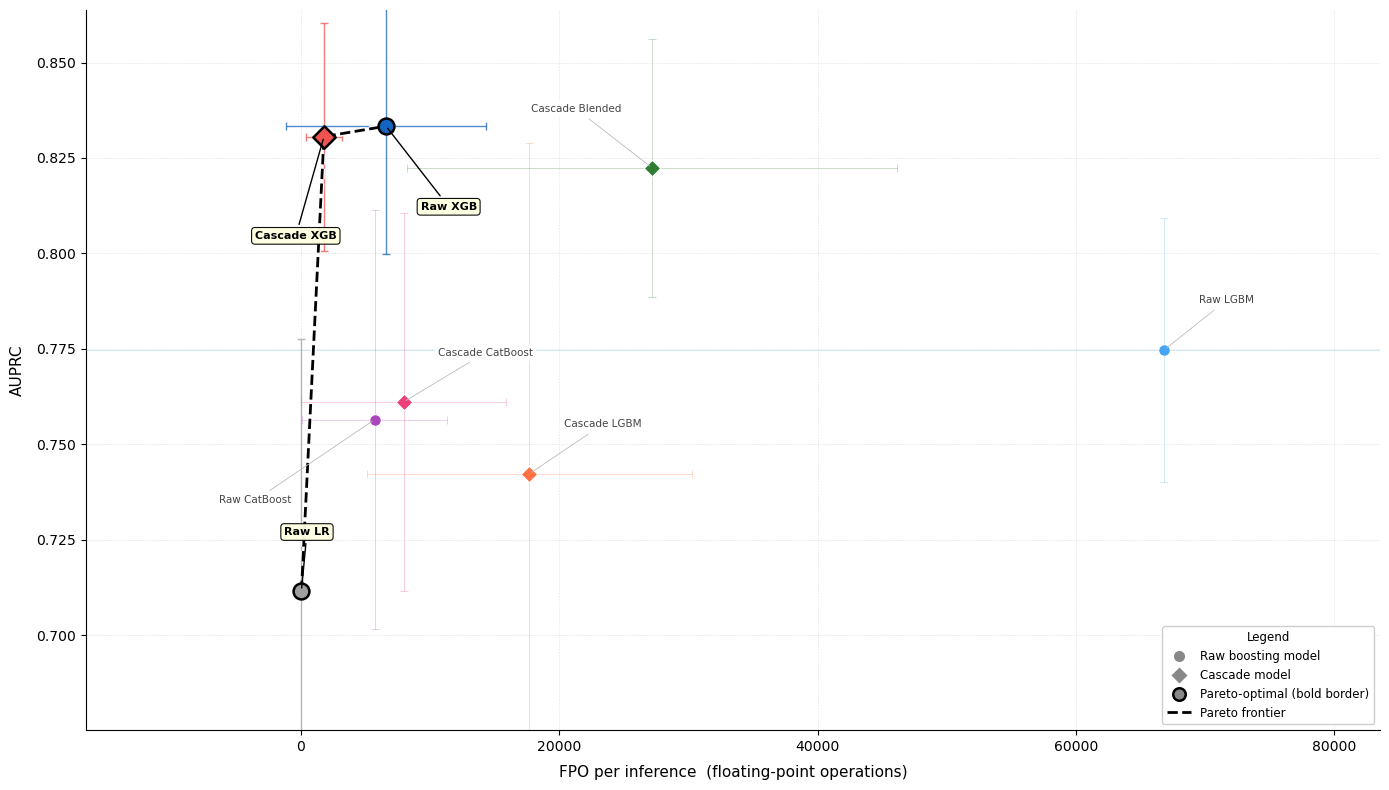

FPO frontier plot saved.

Pareto-optimal models (AUPRC vs FPO):
      model  fpo_mean     fpo_std  auprc_mean  auprc_std
     Raw LR      60.0    0.000000    0.711663   0.065964
Cascade XGB    1804.0 1381.067341    0.830597   0.029851
    Raw XGB    6605.2 7744.613464    0.833339   0.033539


In [16]:
# ════════════════════════════════════════════════════════════════════════════
# PARETO: AUPRC vs FLOPs per inference — all 8 models
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd
import numpy as np

def get_pareto_flops(df):
    """Lower FLOPs + Higher AUPRC = better."""
    pareto = []
    for i, r in df.iterrows():
        dominated = any(
            (o['fpo_mean']    <= r['fpo_mean'] and
             o['auprc_mean']  >= r['auprc_mean'] and
             (o['fpo_mean']   <  r['fpo_mean'] or
              o['auprc_mean'] >  r['auprc_mean']))
            for _, o in df.iterrows() if _ != i
        )
        if not dominated:
            pareto.append(i)
    return df.loc[pareto].sort_values('fpo_mean')

# ── All 12 models ─────────────────────────────────────────────────────────────
ALL_FPO_MODELS = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended',
]

colors_fpo = {
    'Raw LR'             : '#9E9E9E',
    'Raw LGBM'           : '#42A5F5',
    'Raw XGB'            : '#1565C0',
    'Raw CatBoost'       : '#AB47BC',
    'Cascade XGB'        : '#EF5350',
    'Cascade LGBM'       : '#FF7043',
    'Cascade CatBoost'   : '#EC407A',
    'Cascade Blended'    : '#2E7D32',
}

def get_marker(model):
    if 'Raw' in model: return 'o'
    return 'D'

# ── Build points ──────────────────────────────────────────────────────────────
gps_points = []
for model in ALL_FPO_MODELS:
    grp = results_df[results_df['model'] == model]
    if len(grp) == 0:
        continue
    gps_points.append({
        'model'     : model,
        'fpo_mean'  : grp['flops_per_1000'].mean() / 1000,
        'fpo_std'   : grp['flops_per_1000'].std()  / 1000,
        'auprc_mean': grp['auprc'].mean(),
        'auprc_std' : grp['auprc'].std(),
    })

gps_df = pd.DataFrame(gps_points)

# ── Pareto frontier — all 8 models ──────────────────────────────────────────
pareto_gps    = get_pareto_flops(gps_df)
pareto_models = set(pareto_gps['model'].values)

x_range = gps_df['fpo_mean'].max()   - gps_df['fpo_mean'].min()
y_range = gps_df['auprc_mean'].max() - gps_df['auprc_mean'].min()

LABEL_OFFSETS_GPS = {
    'Raw LR'             : (-x_range * 0.02,  y_range * 0.12),
    'Raw LGBM'           : ( x_range * 0.04,  y_range * 0.10),
    'Raw XGB'            : ( x_range * 0.04, -y_range * 0.18),
    'Raw CatBoost'       : (-x_range * 0.18, -y_range * 0.18),
    'Cascade XGB'        : (-x_range * 0.08, -y_range * 0.22),
    'Cascade LGBM'       : ( x_range * 0.04,  y_range * 0.10),
    'Cascade CatBoost'   : ( x_range * 0.04,  y_range * 0.10),
    'Cascade Blended'    : (-x_range * 0.14,  y_range * 0.12),
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Error bars ────────────────────────────────────────────────────────────────
for _, row in gps_df.iterrows():
    is_p = row['model'] in pareto_models
    ax.errorbar(
        row['fpo_mean'], row['auprc_mean'],
        xerr=row['fpo_std'], yerr=row['auprc_std'],
        fmt='none',
        ecolor=colors_fpo.get(row['model'], '#999999'),
        elinewidth=1.0 if is_p else 0.6,
        capsize=3, capthick=1.0 if is_p else 0.6,
        alpha=0.75 if is_p else 0.30,
        zorder=3,
    )

# ── Markers ───────────────────────────────────────────────────────────────────
for _, row in gps_df.iterrows():
    is_p = row['model'] in pareto_models
    ax.scatter(
        row['fpo_mean'], row['auprc_mean'],
        marker=get_marker(row['model']),
        s=130 if is_p else 70,
        color=colors_fpo.get(row['model'], '#999999'),
        edgecolors='black' if is_p else 'white',
        linewidths=1.8 if is_p else 0.8,
        zorder=5,
    )

# ── Pareto frontier line ──────────────────────────────────────────────────────
if len(pareto_gps) > 1:
    ax.plot(
        pareto_gps['fpo_mean'], pareto_gps['auprc_mean'],
        color='black', linestyle='--', linewidth=2.0, zorder=4,
        path_effects=[pe.Stroke(linewidth=4.0, foreground='white'), pe.Normal()],
        label='_nolegend_',
    )

# ── Labels ────────────────────────────────────────────────────────────────────
for _, row in gps_df.iterrows():
    is_p   = row['model'] in pareto_models
    dx, dy = LABEL_OFFSETS_GPS.get(row['model'], (x_range * 0.04, y_range * 0.06))
    ax.annotate(
        row['model'],
        xy=(row['fpo_mean'], row['auprc_mean']),
        xytext=(row['fpo_mean'] + dx, row['auprc_mean'] + dy),
        textcoords='data',
        fontsize=8 if is_p else 7.5,
        fontweight='bold' if is_p else 'normal',
        color='black' if is_p else '#444444',
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='lightyellow' if is_p else 'white',
                  ec='black' if is_p else 'none',
                  alpha=0.95, linewidth=0.8),
        arrowprops=dict(arrowstyle='-',
                        color='black' if is_p else '#bbbbbb',
                        lw=1.0 if is_p else 0.6),
        zorder=7,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markersize=9, label='Raw boosting model'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#888888',
               markersize=9, label='Cascade model'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888',
               markeredgecolor='black', markeredgewidth=1.8,
               markersize=9, label='Pareto-optimal (bold border)'),
    plt.Line2D([0],[0], linestyle='--', color='black',
               linewidth=2.0, label='Pareto frontier'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8.5,
          framealpha=0.95, edgecolor='#cccccc',
          title='Legend', title_fontsize=8.5)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('FPO per inference  (floating-point operations)',
              fontsize=11, labelpad=8)
ax.set_ylabel('AUPRC', fontsize=11, labelpad=8)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35, color='#aaaaaa')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(gps_df['fpo_mean'].min() - x_range * 0.25,
            gps_df['fpo_mean'].max() + x_range * 0.25)
ax.set_ylim(gps_df['auprc_mean'].min() - y_range * 0.30,
            gps_df['auprc_mean'].max() + y_range * 0.25)

plt.tight_layout()
plt.savefig('pareto_gps_auprc_vs_fpo.png', dpi=300, bbox_inches='tight')
plt.show()

print('FPO frontier plot saved.')
print('\nPareto-optimal models (AUPRC vs FPO):')
print(pareto_gps[['model','fpo_mean','fpo_std','auprc_mean','auprc_std']]
      .to_string(index=False))

## Aggregate Training Green Metrics

In [17]:
import glob
import os
import pandas as pd
import numpy as np

_glob_matches = sorted(glob.glob('emissions_base_*.csv'), key=os.path.getmtime)
if not _glob_matches:
    raise FileNotFoundError(
        "No 'emissions_base_*.csv' file found. Make sure the training/inference "
        "loop above (which runs EmissionsTracker) has completed successfully "
        "before running this cell."
    )
em_train = pd.read_csv(_glob_matches[-1])  # FIX: most recently modified emissions file, not a hardcoded UUID

MODEL_KEY_MAP_TRAIN = {
    'CascadeBlended'  : 'Cascade Blended',
    'CascadeCatBoost' : 'Cascade CatBoost',
    'CascadeLGBM'     : 'Cascade LGBM',
    'CascadeXGB'      : 'Cascade XGB',
    'RawCatBoost'     : 'Raw CatBoost',
    'RawLGBM'         : 'Raw LGBM',
    'RawXGB'          : 'Raw XGB',
    'RawLR'           : 'Raw LR',
    'Router'          : None,   # not a standalone comparison row -- attributed
                                 # into each cascade model's total below instead
}

def task_to_model_train(task_name):
    for key in sorted(MODEL_KEY_MAP_TRAIN.keys(), key=len, reverse=True):
        if key in task_name:
            return MODEL_KEY_MAP_TRAIN[key]
    return None

em_train['Model'] = em_train['task_name'].apply(task_to_model_train)
em_train_clean    = em_train.dropna(subset=['Model'])

print("Models in em_train_clean:", sorted(em_train_clean['Model'].unique()))

# ── Measurement Overhead CO2 — real computation, deliberately reported ────────
# The Training-F1 cell above genuinely retrains Raw LGBM/XGB/CatBoost's winning
# configs a second time (their HP-search objects don't persist) solely to score
# training F1 for Train CER. That IS real, additional computation the notebook
# executed -- it is tracked (task names 'measureF1_*'), NOT silently dropped,
# and reported here on its own line so it stays visible and auditable. It is
# excluded from each model's Dev/Search CO2 (and therefore from Train CER)
# because it reproduces a config whose training cost was already counted once
# during the HP search -- tracking it again there would double-count that one
# config's emissions for only 3 of the 8 models, which is a measurement
# artifact of how Train CER was computed, not a real difference in what it
# costs to develop these models.
_measure_mask     = em_train['task_name'].str.contains('measureF1_', na=False)
measure_co2_kg    = em_train.loc[_measure_mask, 'emissions'].sum()
measure_dur_s     = em_train.loc[_measure_mask, 'duration'].sum()
measure_kwh       = em_train.loc[_measure_mask, 'energy_consumed'].sum()
measure_n_tasks   = int(_measure_mask.sum())

print(f"\nMeasurement Overhead CO2 (Training-F1 extra retrains — excluded from Dev/Search CO2 and Train CER):")
print(f"  CO₂: {measure_co2_kg:.6f} kg | Dur: {measure_dur_s:.1f} s | "
      f"Energy: {measure_kwh:.6f} kWh | Tasks: {measure_n_tasks}")

# ── Sum across all HP trials ──────────────────────────────────────────────
# NOTE: this is a genuine, correctly-computed sum -- but it answers
# "how much carbon did the full development/hyperparameter-search process
# cost?", NOT "how much carbon does training the final, selected model cost?"
# These are two different quantities. The former (computed here) includes
# every rejected candidate's training run; the latter would require isolating
# emissions for only the winning hyperparameter configuration per seed (the
# same approach used for inference in the cell above). Both are legitimate
# to report, but they should be labeled distinctly rather than both called
# "training cost" -- this DataFrame reports DEVELOPMENT/SEARCH cost.
# (Raw LR's post-search "retrain for cascade reuse" is intentionally NOT
# tracked/summed here -- it re-trains an already-explored candidate purely
# to get a reusable pipeline object, so counting it would double-count that
# one config's emissions relative to every other model's HP trials.)
train_agg = em_train_clean.groupby('Model').agg(
    total_co2_kg     = ('emissions',       'sum'),
    total_dur_s      = ('duration',        'sum'),
    total_energy_kwh = ('energy_consumed', 'sum'),
    n_tasks          = ('emissions',       'count'),
).reset_index()

# ── Router + LR training cost — shared components, required by every cascade ──
# The AdaBoost router isn't hyperparameter-searched (one config per seed), but
# its training emissions ARE a real, necessary part of building every cascade
# system (Stage-1 LR -> Router -> Stage-2 booster). Excluding it entirely (as
# before) understates every cascade model's true development footprint.
_router_mask      = em_train['task_name'].str.contains('train_Router_AdaBoost', na=False)
router_train_co2  = em_train.loc[_router_mask, 'emissions'].sum()
router_train_dur  = em_train.loc[_router_mask, 'duration'].sum()
router_train_kwh  = em_train.loc[_router_mask, 'energy_consumed'].sum()

print(f"\nRouter (AdaBoost) training cost — shared across all cascade models:")
print(f"  CO₂: {router_train_co2:.6f} kg | Dur: {router_train_dur:.1f} s | Energy: {router_train_kwh:.6f} kWh")

def get_train_val(model, col):
    row = train_agg[train_agg['Model'] == model]
    return float(row[col].values[0]) if len(row) > 0 else 0.0

# ── Stage-1 LR training cost — the OTHER shared component every cascade needs ──
# Every cascade (Stage-1 LR -> Router -> Stage-2 booster) requires a fitted LR
# to produce the Stage-1 probability the Router and Stage-2 models consume.
# We don't retrain LR again here (its post-search "retrain for cascade reuse"
# is deliberately not tracked -- see note below), so instead we attribute the
# ALREADY-RECORDED Raw LR dev/search cost (all C-value trials, same convention
# used for every other model's Dev/Search CO2 in this table) to each cascade
# model as its shared Stage-1 component. This is a real, once-incurred cost of
# building the cascade -- omitting it understated every cascade model's true
# development footprint, exactly like omitting Router did.
lr_train_co2 = get_train_val('Raw LR', 'total_co2_kg')
lr_train_dur = get_train_val('Raw LR', 'total_dur_s')
lr_train_kwh = get_train_val('Raw LR', 'total_energy_kwh')

print(f"\nStage-1 LR training cost (Raw LR dev/search, attributed to every cascade):")
print(f"  CO₂: {lr_train_co2:.6f} kg | Dur: {lr_train_dur:.1f} s | Energy: {lr_train_kwh:.6f} kWh")

# ── Cascade Blended training cost = ACTUAL computation performed ──────────────
# Blended has no independent training of its own, but it DOES require: the
# Stage-1 LR, the shared Router, AND all three Stage-2 boosters (LGBM, XGB,
# CatBoost) to be fully trained. wl/wx/wc are prediction-BLEND weights, not a
# measure of how much training computation happened -- they must not be used
# to discount component training cost. Fixed the same way inference CO2 was
# already fixed above (cell 18): SUM the real components' costs, not a
# weighted average. The pre-router-attribution values of Cascade LGBM/XGB/
# CatBoost in train_agg are used here (stage-2-only), so LR and Router are
# each added exactly once for Blended -- not once per component.
blended_co2 = (
    lr_train_co2 +
    router_train_co2 +
    get_train_val('Cascade LGBM',    'total_co2_kg') +
    get_train_val('Cascade XGB',     'total_co2_kg') +
    get_train_val('Cascade CatBoost','total_co2_kg')
)
blended_dur = (
    lr_train_dur +
    router_train_dur +
    get_train_val('Cascade LGBM',    'total_dur_s') +
    get_train_val('Cascade XGB',     'total_dur_s') +
    get_train_val('Cascade CatBoost','total_dur_s')
)
blended_kwh = (
    lr_train_kwh +
    router_train_kwh +
    get_train_val('Cascade LGBM',    'total_energy_kwh') +
    get_train_val('Cascade XGB',     'total_energy_kwh') +
    get_train_val('Cascade CatBoost','total_energy_kwh')
)

print(f"\nCascade Blended training cost (actual computation: LR + Router + LGBM + XGB + CatBoost):")
print(f"  CO₂  : {blended_co2:.6f} kg")
print(f"  Dur  : {blended_dur:.1f} s")
print(f"  Energy: {blended_kwh:.6f} kWh")

# ── Patch Cascade Blended into train_agg ─────────────────────────────────────
if 'Cascade Blended' not in train_agg['Model'].values:
    train_agg = pd.concat([train_agg, pd.DataFrame([{
        'Model'           : 'Cascade Blended',
        'total_co2_kg'    : blended_co2,
        'total_dur_s'     : blended_dur,
        'total_energy_kwh': blended_kwh,
        'n_tasks'         : 'LR+router+3 components',
    }])], ignore_index=True)
else:
    train_agg.loc[train_agg['Model'] == 'Cascade Blended', 'total_co2_kg']     = blended_co2
    train_agg.loc[train_agg['Model'] == 'Cascade Blended', 'total_dur_s']      = blended_dur
    train_agg.loc[train_agg['Model'] == 'Cascade Blended', 'total_energy_kwh'] = blended_kwh

# ── Attribute LR + Router cost to the other 3 standalone cascade models too ───
# Cascade XGB / LGBM / CatBoost, run as standalone systems, also require a
# fitted Stage-1 LR and the Router to route transactions to them -- same
# principle as Blended above. Applied AFTER computing blended_co2 (which read
# the pre-attribution, stage-2-only values), so LR and Router are each added
# exactly once per model, never compounded across this step and the Blended
# sum.
for _casc_model in ['Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost']:
    _mask = train_agg['Model'] == _casc_model
    if _mask.any():
        train_agg.loc[_mask, 'total_co2_kg']     += lr_train_co2 + router_train_co2
        train_agg.loc[_mask, 'total_dur_s']      += lr_train_dur + router_train_dur
        train_agg.loc[_mask, 'total_energy_kwh'] += lr_train_kwh + router_train_kwh

# ── All 8 models — no Router ───────────────────────────────────────────────────
ALL_TRAIN_MODELS = [
    'Raw LR', 'Raw LGBM', 'Raw XGB', 'Raw CatBoost',
    'Cascade XGB', 'Cascade LGBM', 'Cascade CatBoost', 'Cascade Blended',
]

# ── Build table ───────────────────────────────────────────────────────────────
train_table_rows = []
for model in ALL_TRAIN_MODELS:
    row = train_agg[train_agg['Model'] == model]
    if len(row) == 0:
        train_table_rows.append({
            'Model'                   : model,
            'Dev/Search CO₂ (kg)'    : 'N/A',
            'Dev/Search Duration (s)' : 'N/A',
            'Dev/Search Energy (kWh)' : 'N/A',
            'HP Trials (n)'           : 'N/A',
            'Train F1 (mean)'         : 'N/A',
            'Train CER'               : 'N/A',
        })
        continue

    total_co2 = float(row['total_co2_kg'].values[0])
    total_dur = float(row['total_dur_s'].values[0])
    total_kwh = float(row['total_energy_kwh'].values[0])
    n_tasks   = row['n_tasks'].values[0]
    n_str     = str(n_tasks) if isinstance(n_tasks, str) else int(n_tasks)

    # Train CER = training-set F1 / Dev-Search CO2 -- both sides now come
    # from the SAME phase (the winning config's fit on its own training
    # data, over the full dev/search CO2 that produced it), so this is a
    # valid relative "carbon per unit of training fit" ranking across
    # models. It intentionally does NOT use test/validation F1 -- see the
    # notebook discussion above for why that would be phase-mismatched.
    grp     = results_df[results_df['model'] == model]
    f1_str  = 'N/A'
    cer_str = 'N/A'
    if len(grp) > 0 and 'train_f1' in grp.columns:
        train_f1_mean = grp['train_f1'].mean()
        f1_str        = f"{train_f1_mean:.4f}"
        cer_str       = f"{train_f1_mean / total_co2:,.1f}" if total_co2 > 0 else 'N/A'

    train_table_rows.append({
        'Model'                   : model,
        'Dev/Search CO₂ (kg)'    : f"{total_co2:.6f}",
        'Dev/Search Duration (s)' : f"{total_dur:.1f}",
        'Dev/Search Energy (kWh)' : f"{total_kwh:.6f}",
        'HP Trials (n)'           : n_str,
        'Train F1 (mean)'         : f1_str,
        'Train CER'               : cer_str,
    })

train_df = pd.DataFrame(train_table_rows)

print('\n📊 TRAINING ENVIRONMENTAL COST TABLE — All 8 Models\n')
print(train_df.to_string(index=False))
print('\nNotes:')
print('  Training is a one-time cost — not repeated at inference.')
print('  Train F1 = winning config scored on its OWN training data, using the')
print('  validation-selected threshold (relative ranking, not a generalization claim).')
print('  Train CER = Train F1 / Dev-Search CO₂ (kg)  ↑ higher = more carbon-efficient')
print('  per unit of training fit. Same-phase ratio — comparable across models,')
print('  not intended to be compared against the inference-phase CER.')
print('  Cascade Blended training cost = LR + Router + LGBM + XGB + CatBoost (actual')
print('  computation performed — a sum, not a weighted average of blend weights).')
print('  Stage-1 LR training cost (Raw LR dev/search) AND Router (AdaBoost) training')
print('  cost are each added once to every cascade model — Cascade XGB, Cascade LGBM,')
print('  Cascade CatBoost, and Cascade Blended. Both are required, shared components')
print('  of every cascade system (Stage-1 LR -> Router -> Stage-2 booster), so both')
print('  are included in each system\'s own development footprint rather than')
print('  excluded or attributed only to Raw LR / shown once.')
print(f'  Measurement Overhead CO2 ({measure_co2_kg:.6f} kg, {measure_n_tasks} tasks): real, tracked')
print('  computation (extra retrains needed only to score Train F1) — reported')
print('  above, excluded from Dev/Search CO2 and Train CER by design, not omission.')

train_df.to_csv('table_training_green_metrics.csv', index=False)
print('\n✅  Saved → table_training_green_metrics.csv')



Models in em_train_clean: ['Cascade Blended', 'Cascade CatBoost', 'Cascade LGBM', 'Cascade XGB', 'Raw CatBoost', 'Raw LGBM', 'Raw LR', 'Raw XGB']

Measurement Overhead CO2 (Training-F1 extra retrains — excluded from Dev/Search CO2 and Train CER):
  CO₂: 0.000000 kg | Dur: 0.0 s | Energy: 0.000000 kWh | Tasks: 0

Router (AdaBoost) training cost — shared across all cascade models:
  CO₂: 0.000000 kg | Dur: 0.0 s | Energy: 0.000000 kWh

Stage-1 LR training cost (Raw LR dev/search, attributed to every cascade):
  CO₂: 0.000080 kg | Dur: 18.0 s | Energy: 0.000115 kWh

Cascade Blended training cost (actual computation: LR + Router + LGBM + XGB + CatBoost):
  CO₂  : 0.000296 kg
  Dur  : 65.9 s
  Energy: 0.000428 kWh

📊 TRAINING ENVIRONMENTAL COST TABLE — All 8 Models

           Model Dev/Search CO₂ (kg) Dev/Search Duration (s) Dev/Search Energy (kWh)  HP Trials (n) Train F1 (mean) Train CER
          Raw LR            0.000080                    18.0                0.000115             35   

Training CER ranking:
           model    cer     f1      co2
         Raw XGB 7020.6 0.5074 0.000072
    Raw CatBoost 6167.5 0.4157 0.000067
        Raw LGBM 4352.1 0.3627 0.000083
          Raw LR 4306.4 0.3428 0.000080
     Cascade XGB 3634.0 0.5483 0.000151
Cascade CatBoost 3056.4 0.4495 0.000147
    Cascade LGBM 3045.7 0.4784 0.000157
 Cascade Blended 1690.5 0.5000 0.000296


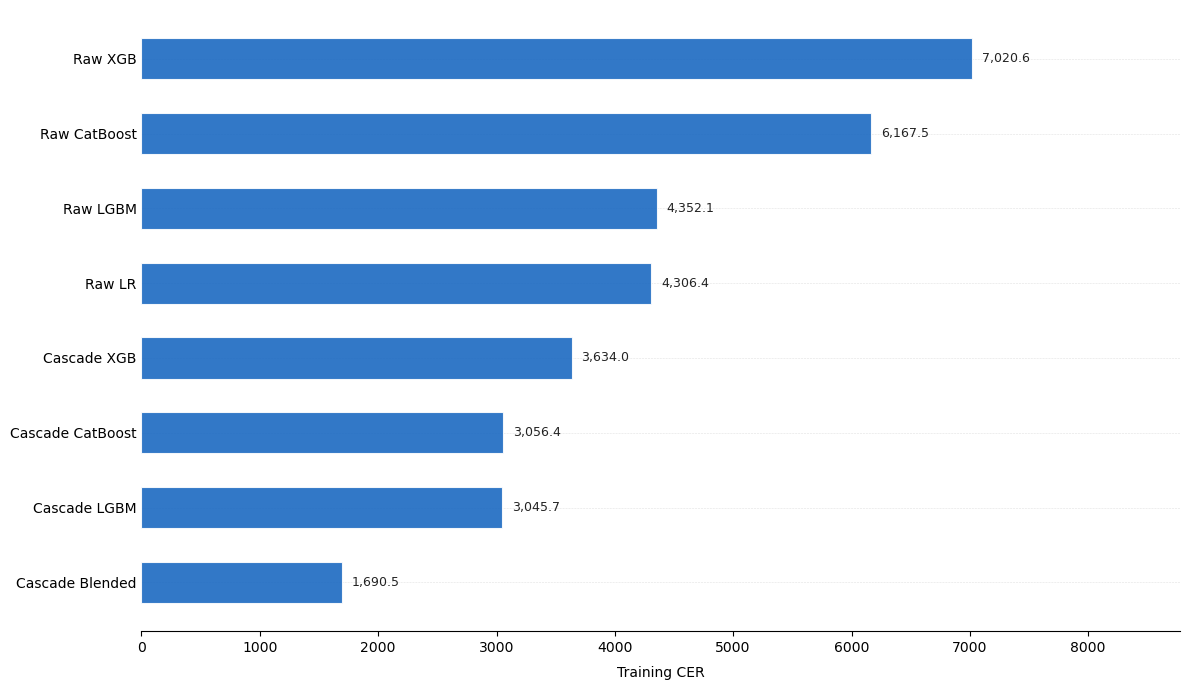

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ── Build CER data from train_df ──────────────────────────────────────────────
cer_train_rows = []
for _, row in train_df.iterrows():
    if row['Train CER'] == 'N/A' or row['Train F1 (mean)'] == 'N/A':
        continue
    cer_train_rows.append({
        'model': row['Model'],
        'cer'  : float(str(row['Train CER']).replace(',', '')),
        'f1'   : float(row['Train F1 (mean)']),
        'co2'  : float(row['Dev/Search CO₂ (kg)']),
    })

plot_df = pd.DataFrame(cer_train_rows).sort_values('cer', ascending=True).reset_index(drop=True)

print('Training CER ranking:')
print(plot_df[['model', 'cer', 'f1', 'co2']]
      .sort_values('cer', ascending=False).to_string(index=False))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y_pos  = np.arange(len(plot_df))
x_max  = plot_df['cer'].max()

bars = ax.barh(
    y_pos, plot_df['cer'],
    height=0.55,
    color='#1565C0',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.88,
)

# ── Value labels at end of each bar ───────────────────────────────────────────
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row['cer'] + x_max * 0.012, i,
        f"{row['cer']:,.1f}",
        va='center', ha='left',
        fontsize=9, fontweight='normal', color='#222222',
    )

# ── Y-axis tick labels — all black ───────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['model'], fontsize=10, color='black')

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel(
    'Training CER',
    fontsize=10, labelpad=8,
)
ax.set_xlim(0, x_max * 1.25)

# ── Horizontal grid lines only ────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.35, color='#aaaaaa')
ax.xaxis.grid(False)
ax.set_axisbelow(True)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig('training_cer_barchart.png', dpi=300, bbox_inches='tight')
plt.show()
